# Comparison of individual parcellations using task vs. resting prior

This jupyter notebook is to demenstrate a comparison between different individual parcellations generated from group priors of different modalities.

In [42]:
import time
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import FusionModel.util as futil
import FusionModel.evaluate as ev
import utils as ut

In [43]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')

# from global_config import MODEL_DIR, BASE_DIR, ATLAS_DIR, DEVICE
# from scripts.group_parcellation import build_ukb_datasets, convert_hard_to_prob, get_indiv_parcellation_from_model
# from scripts.indiv_eval import *

# Individual parcellation generation

## Group priors: Pure resting-state vs. task-based fusion

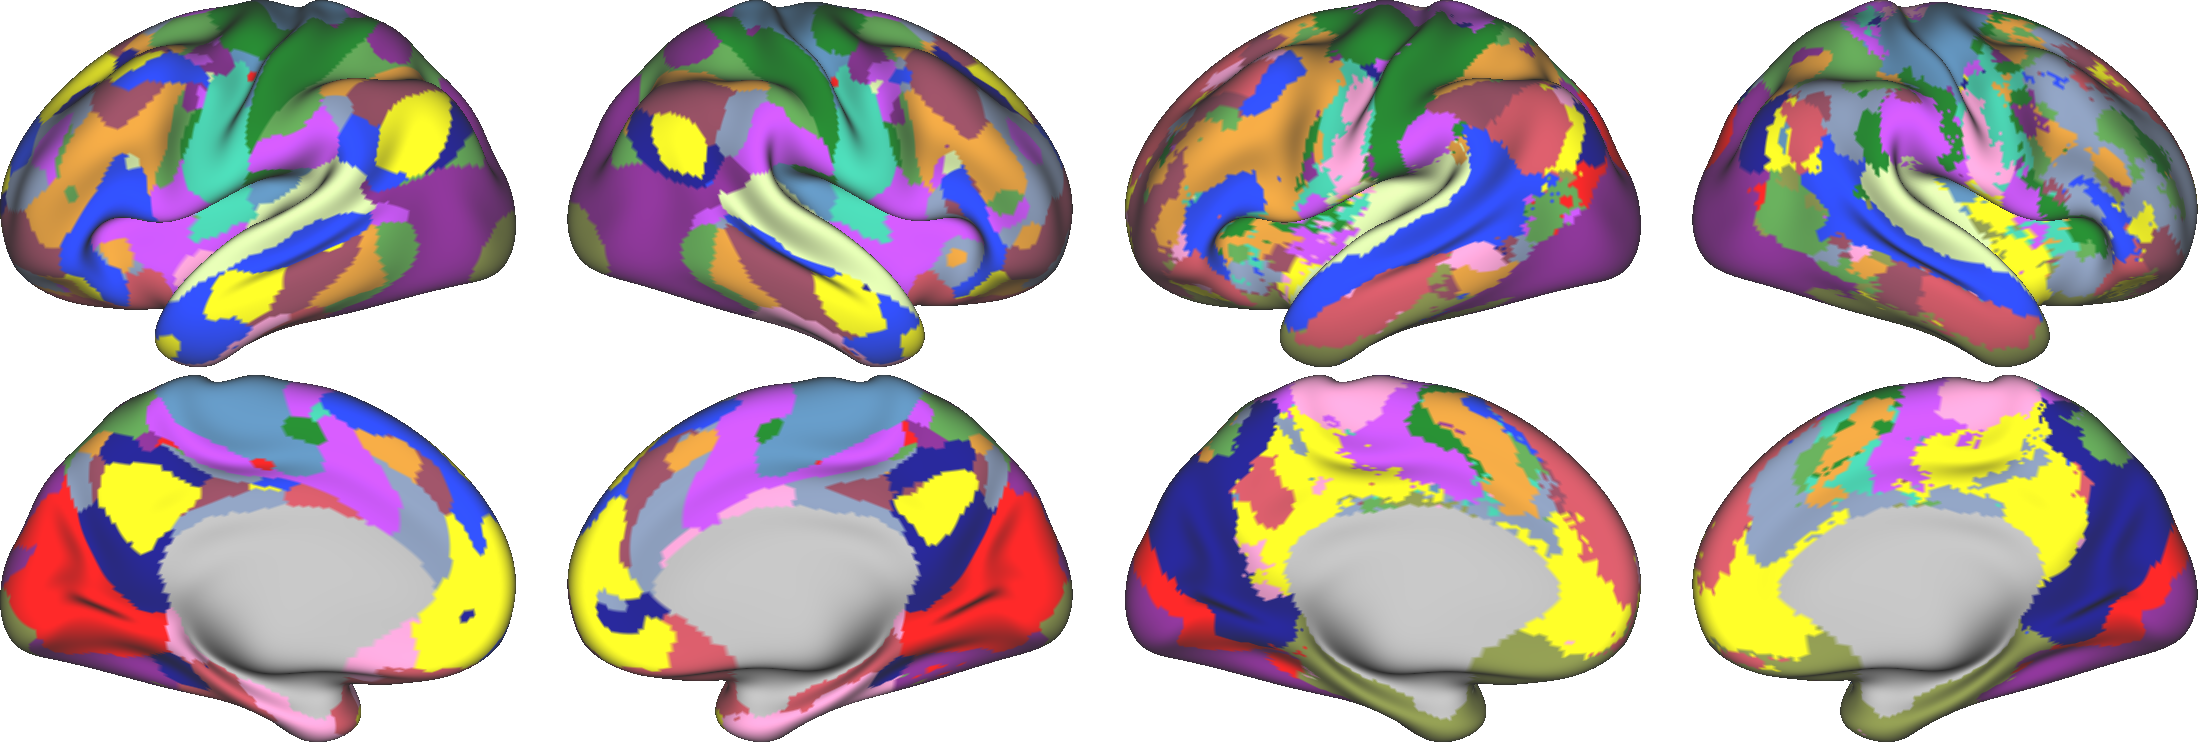

In [6]:
from IPython.display import Image, display, HTML

# Display the image with a caption
display(Image(filename='/PHShome/dz010/Documents/group_resting_vs_task.png'))
display(HTML("<p style='text-align:center;'> HBP resting-state (HCP 800 subjects) ------------------ HBP task-based fusion (6 datasets 87 subjects) </p>"))

## Option 1: Precision mapping using MDTB task individual data 

## (a) with resting prior

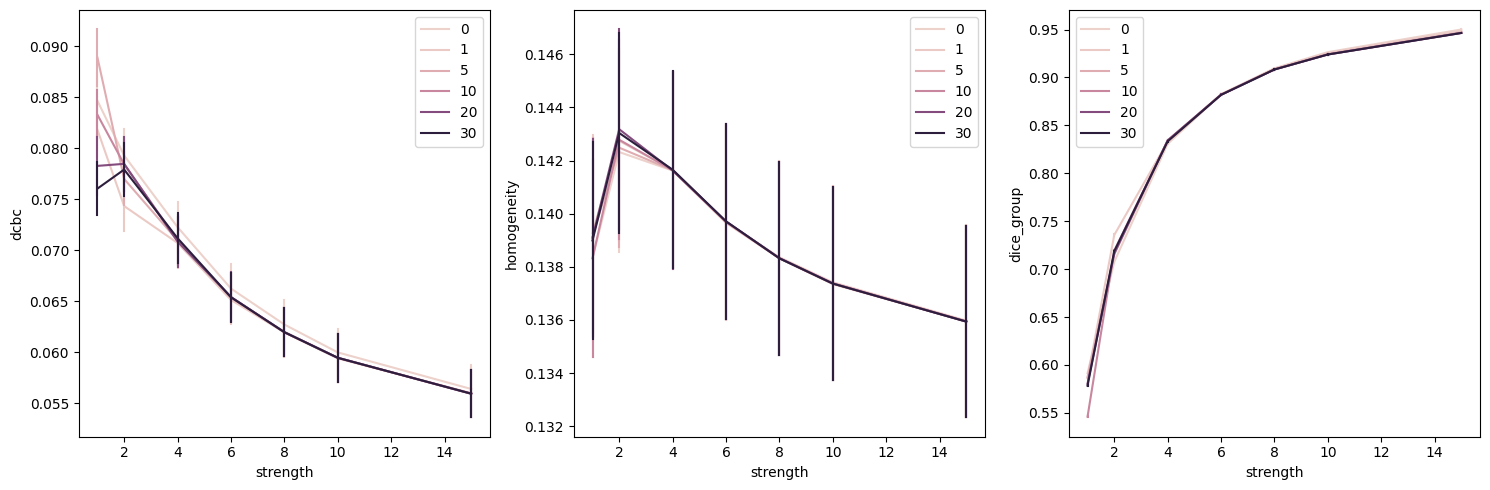

In [7]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

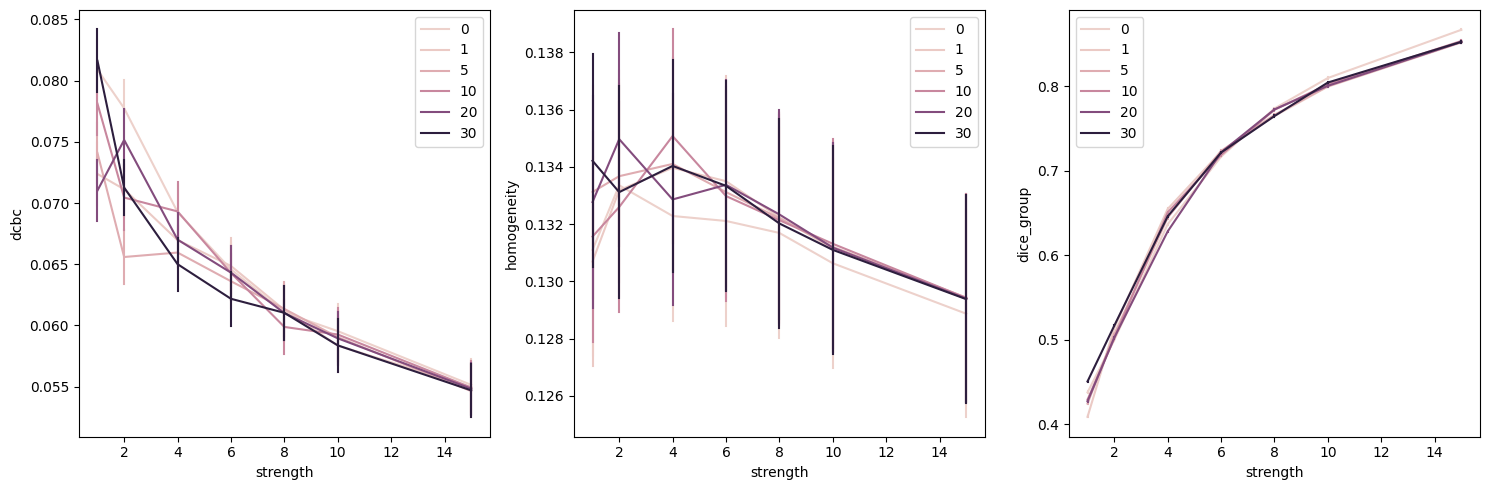

In [17]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_6taskfusion+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('dcbc')
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)

plt.ylabel('homogeneity')
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se",
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (c) Comparing

['CPRO' 'prediction' 'verbGeneration' 'spatialNavigation' 'spatialMap'
 'natureMovie' 'romanceMovie' 'landscapeMovie' 'motorSequence'
 'mentalRotation' 'nBackPic' 'emotionProcess' 'respAlt' 'visualSearch'
 'ToM' 'actionObservation' 'rest' 'all']


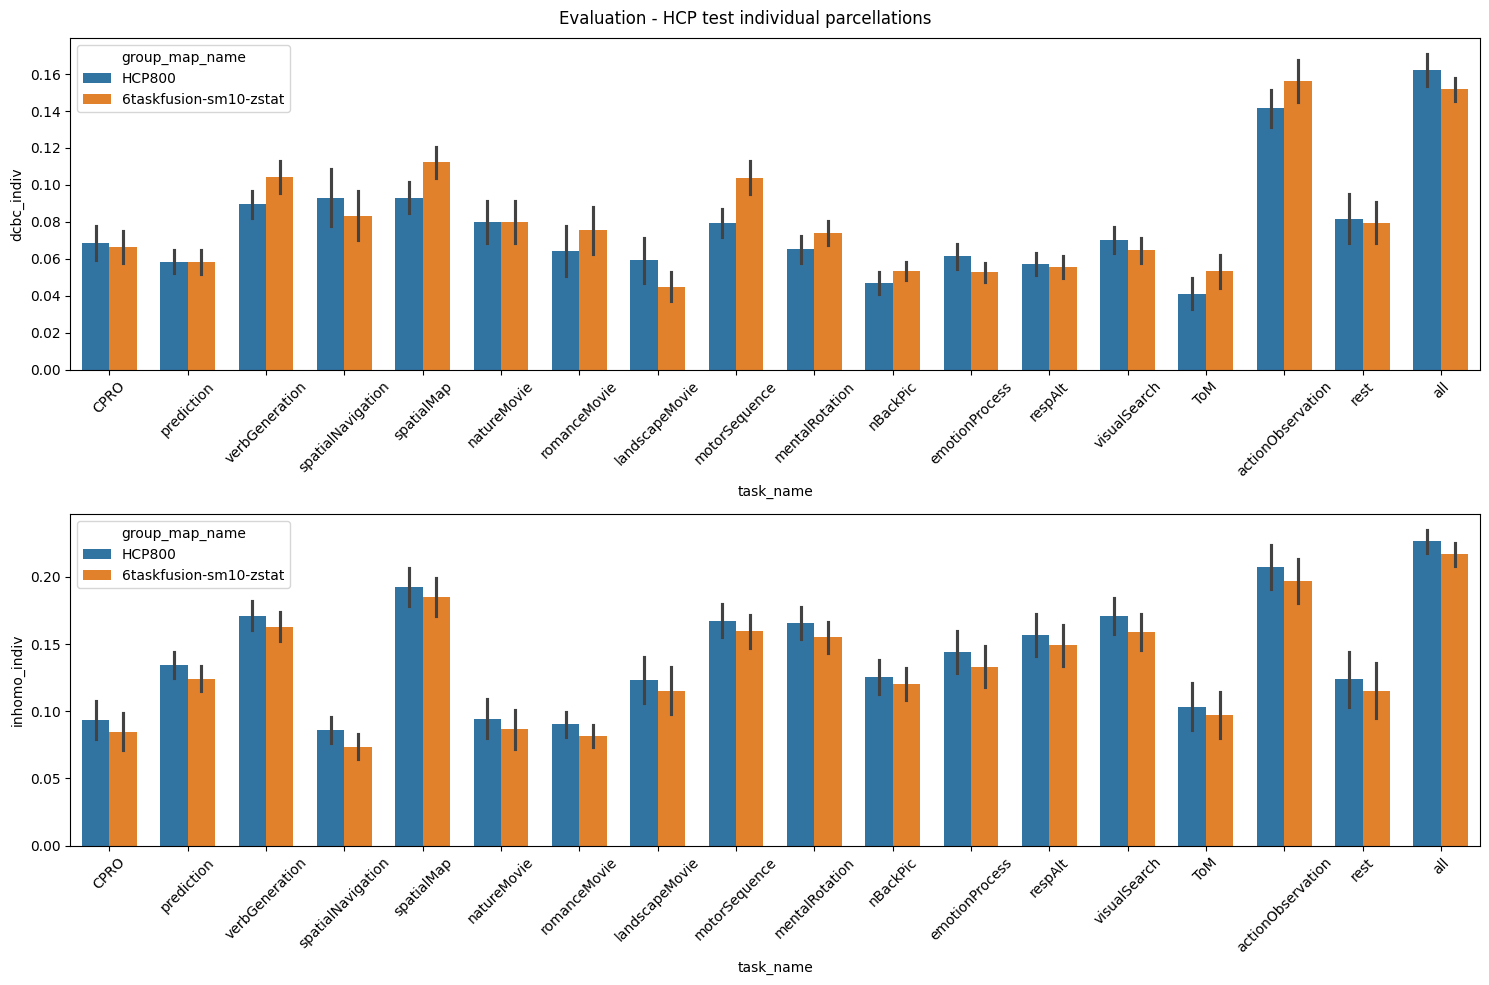

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]

# results = results.replace(results.task_name.unique(), ['Executive', 'Social', 'Motor', 'Emotion', 'Numerical', 'Perception',
#                                           'Emotion', 'Temporal', 'Motor', 'Motor', 'Executive', 'Executive', 'Spatial',
#                                           'Executive', 'Language', 'Perception', 'Rest', 'Executive', 'Executive',
#                                           'Spatial', 'Social', 'Social', 'Perception', 'Spatial', 'Emotion', 'Motor'])

results2 = pd.read_csv(RES_DIR + f'/eval_6taskfusion+Md-ses1_indiv_test_on_Md-ses2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 1) & (results2['spatial_w'] == 30)]

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='group_map_name', 
           errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.show()

## Option 2: Precision mapping using HCP task individual data 

## (a) with resting prior

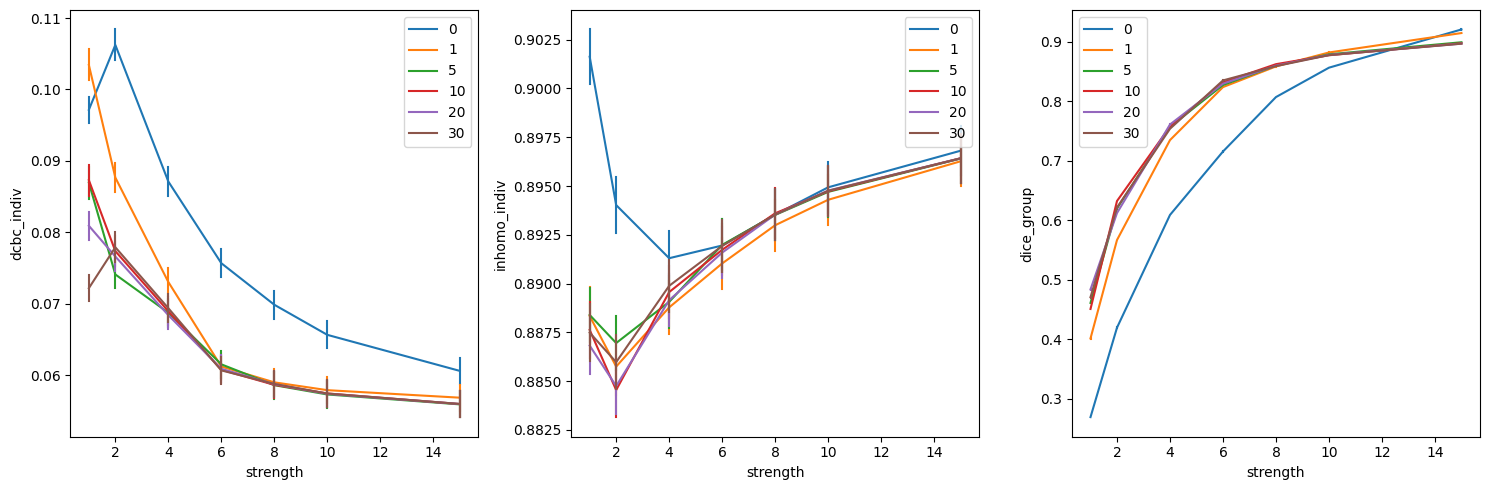

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

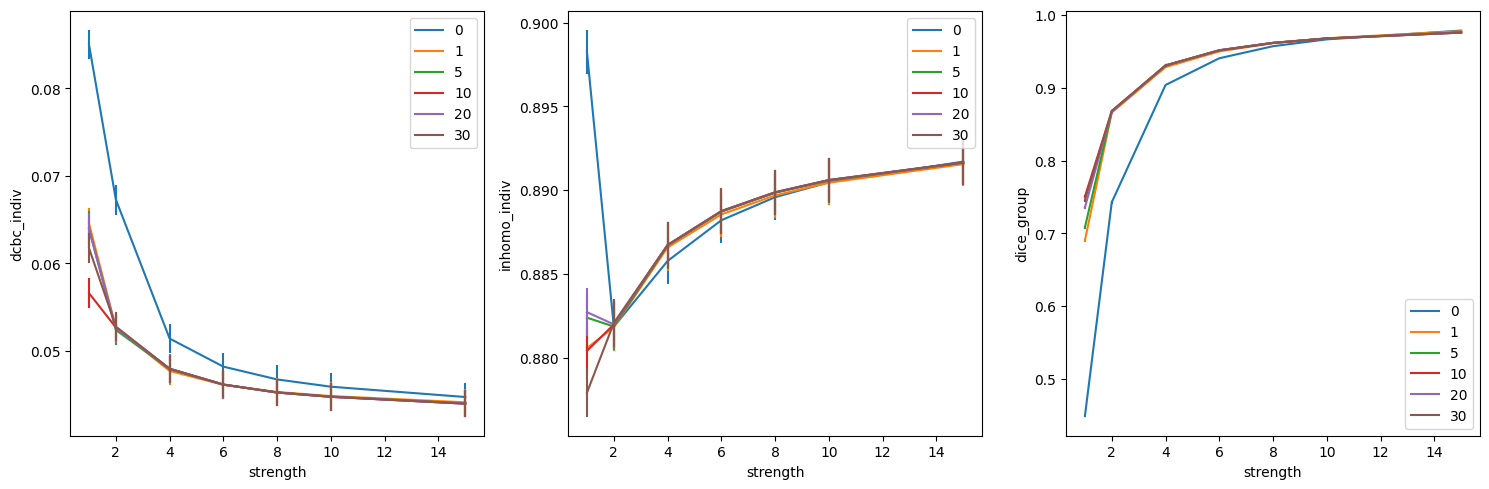

In [10]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')

# results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40-ROI1483_on_HCP40validation_groupstrength-1to120_spatialW-0to120.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['EMOTION' 'GAMBLING' 'LANGUAGE' 'MOTOR' 'RELATIONAL' 'SOCIAL' 'WM' 'all']


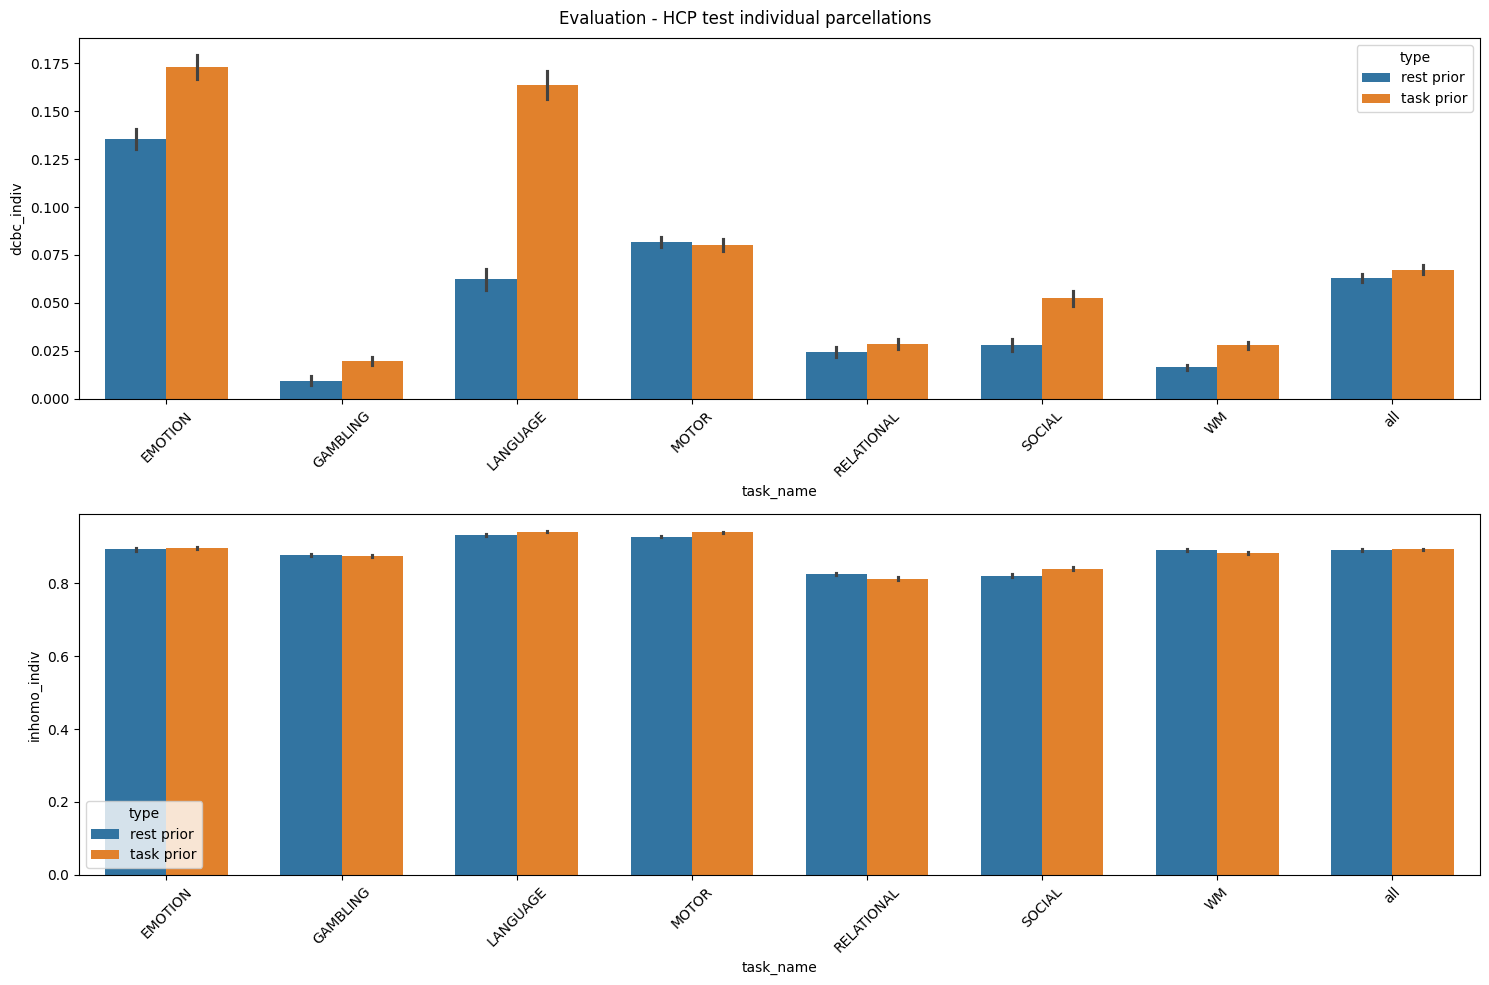

In [16]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]
results1['type'] = 'rest prior'
results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+HCPtask-half1_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 20)]
results2['type'] = 'task prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## K = 15

['EMOTION' 'GAMBLING' 'LANGUAGE' 'MOTOR' 'RELATIONAL' 'SOCIAL' 'WM' 'all']


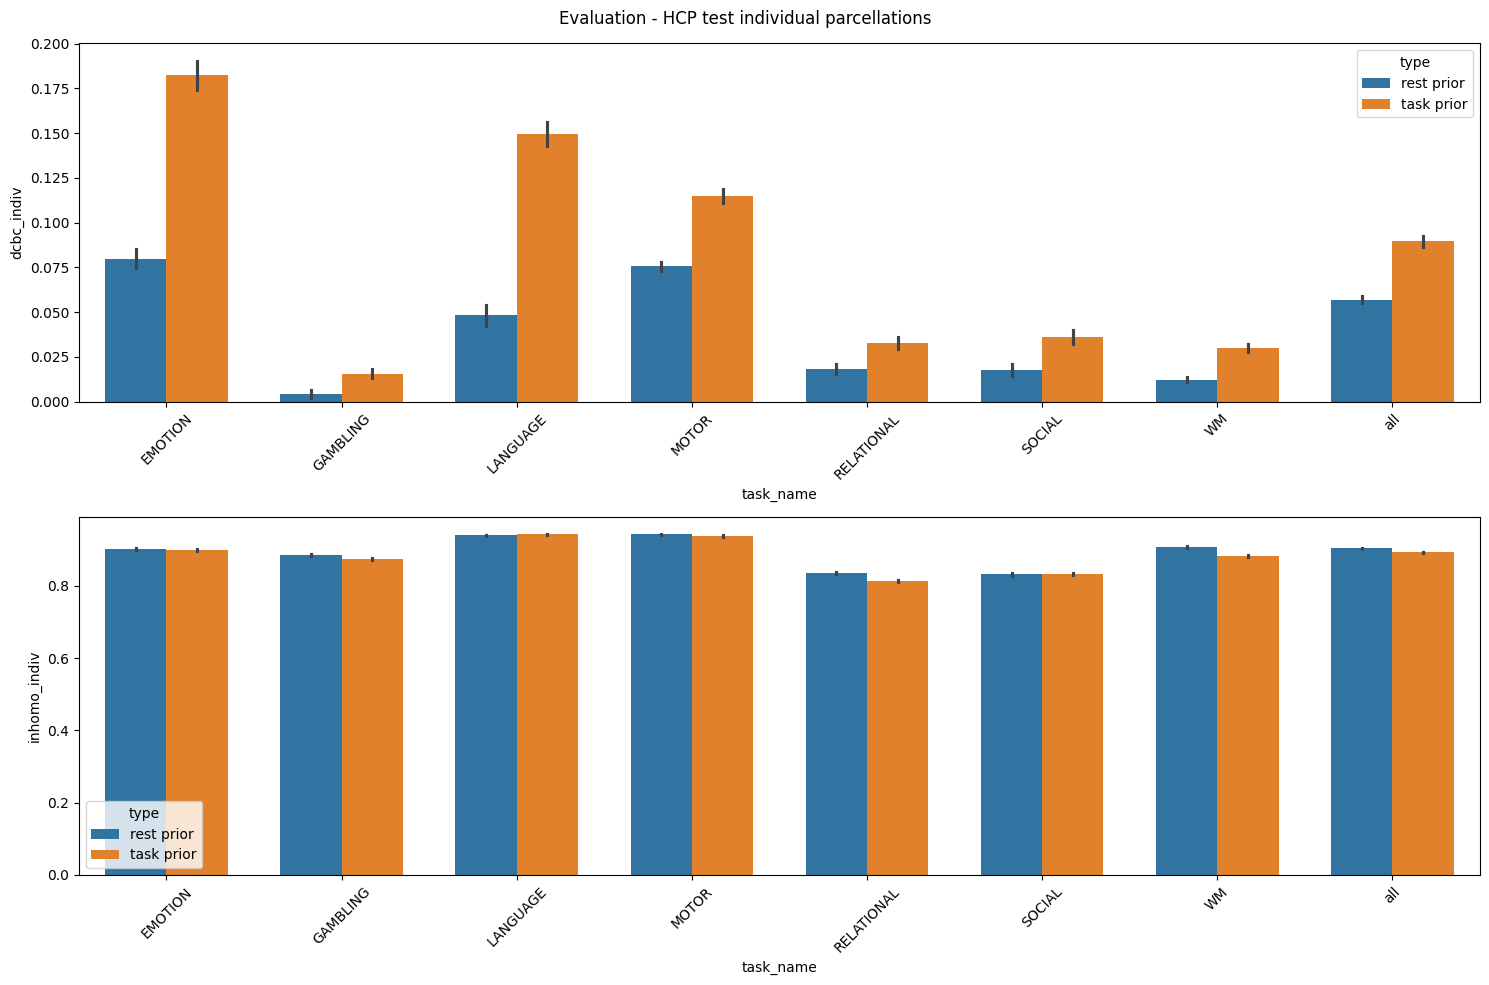

In [3]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP40+HCPtask-half1_K-15_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 20)]
results1['type'] = 'rest prior'
results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+HCPtask-half1_K-15_indiv-WcRBM_test_on_HCPtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 20)]
results2['type'] = 'task prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.xticks(rotation=45)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## Option 2: Precision mapping using MSC task individual data 

## (a) with resting prior

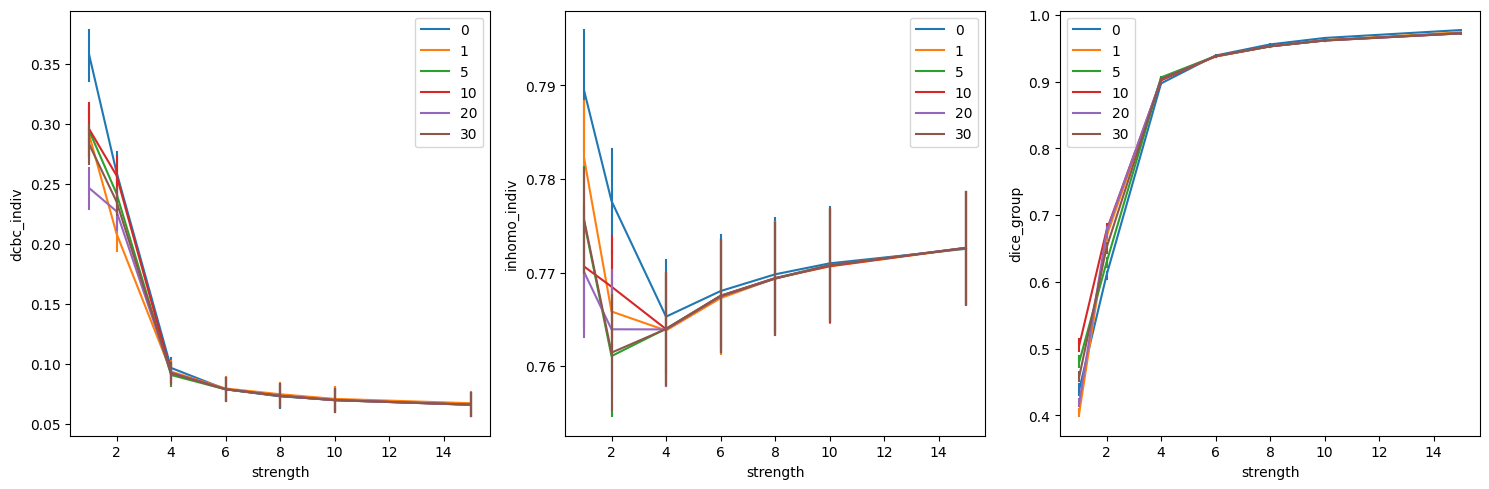

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (b) with task prior

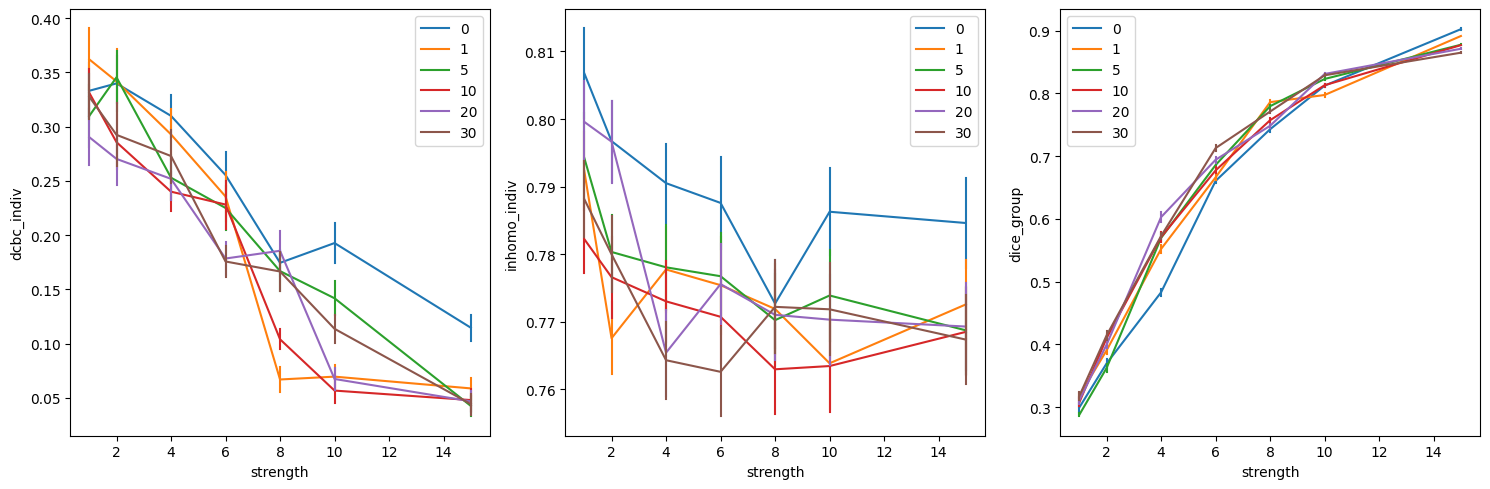

In [4]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## (c) with existing resting prior (Kong 2019)

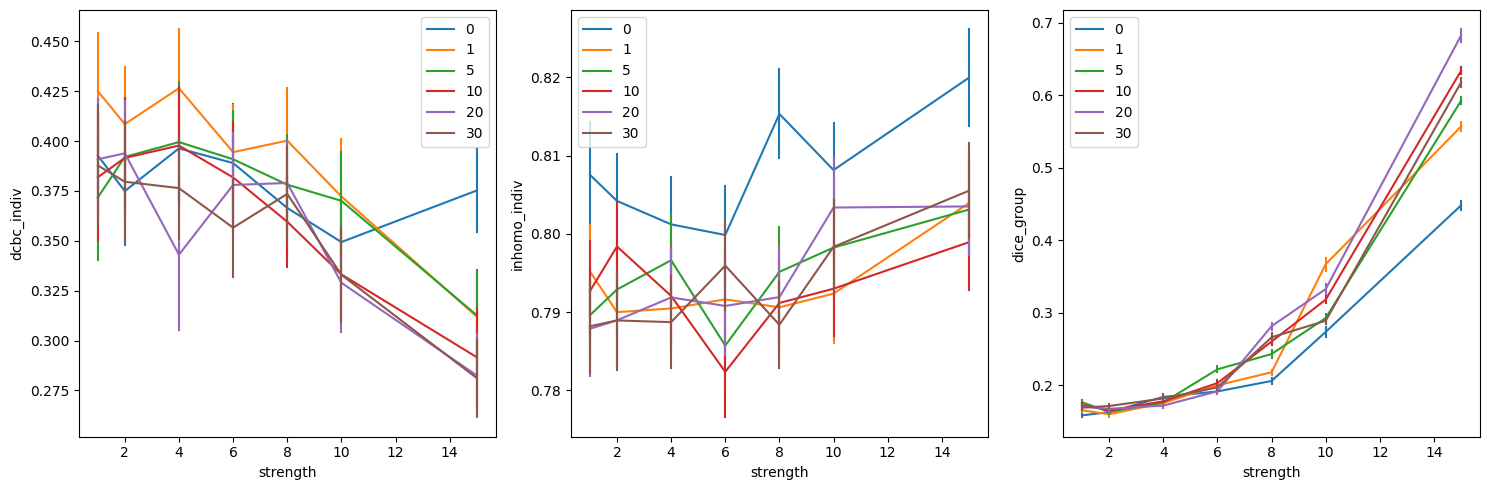

In [5]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## K=17 comparison

['motor' 'mem' 'mixed' 'all']


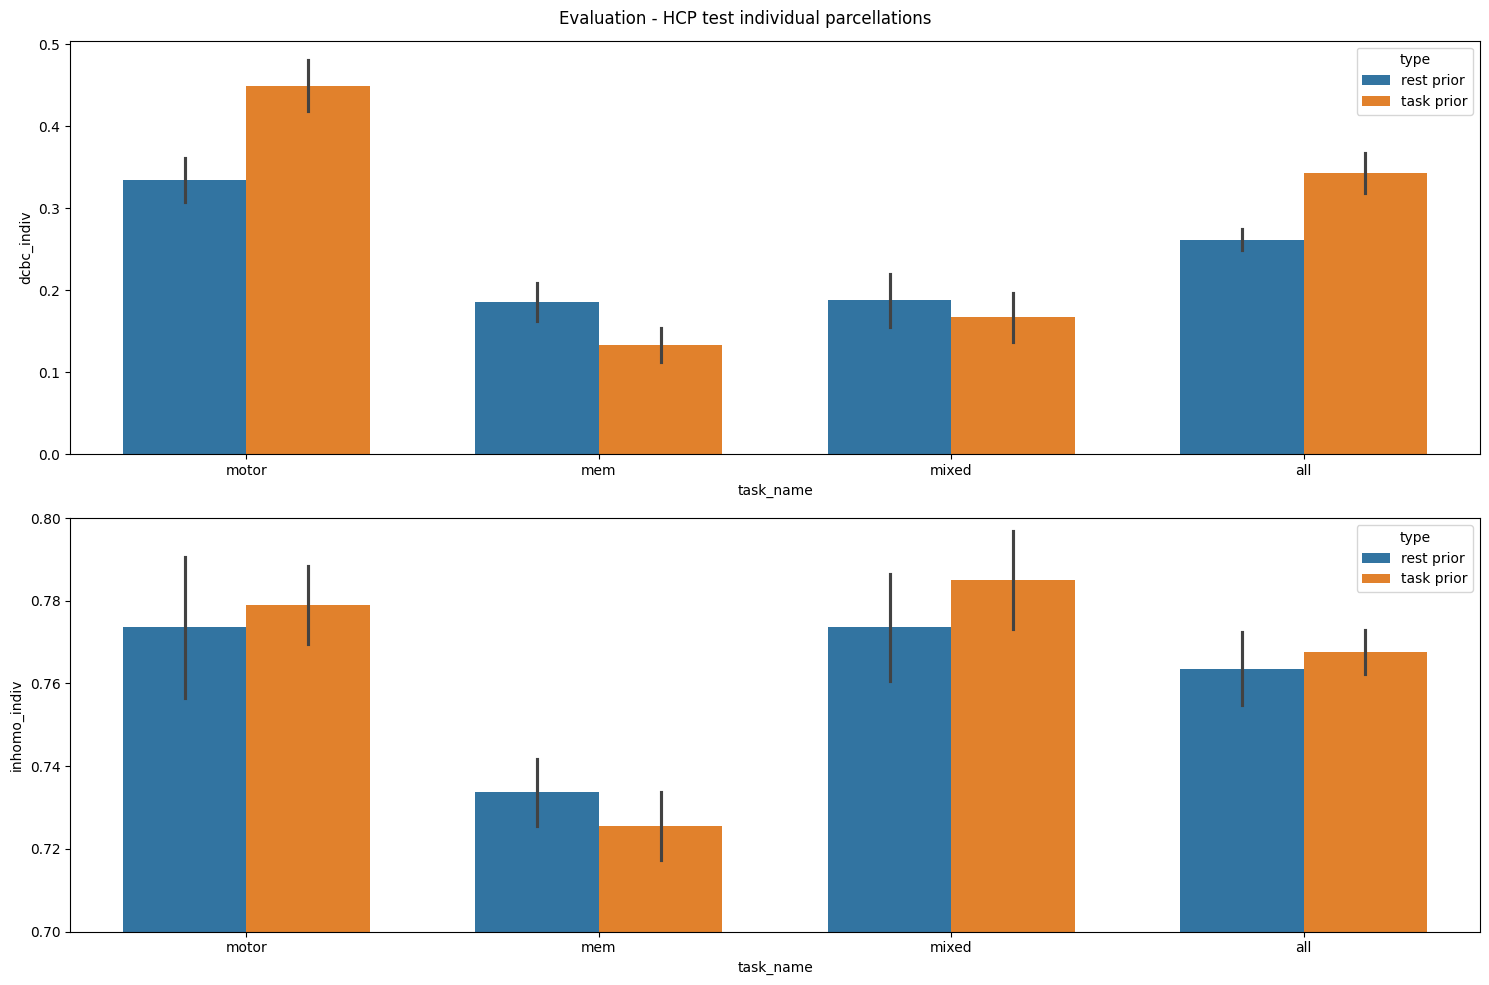

In [5]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4) & (results2['spatial_w'] == 30)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.8)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## K =15 comparison

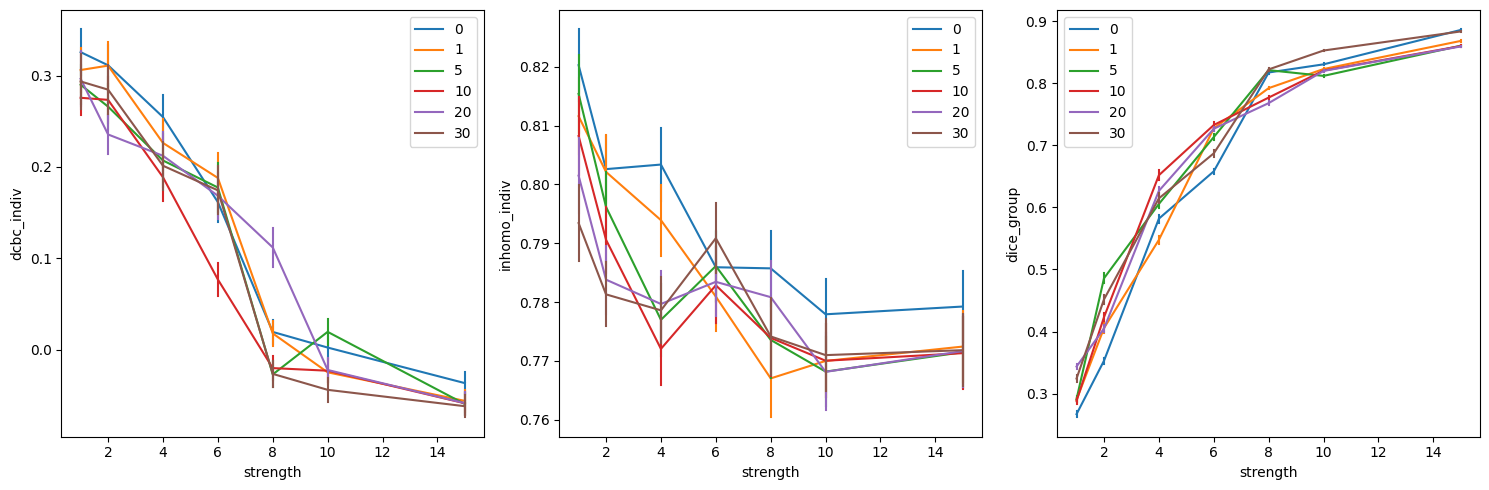

In [5]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_7taskfusion+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

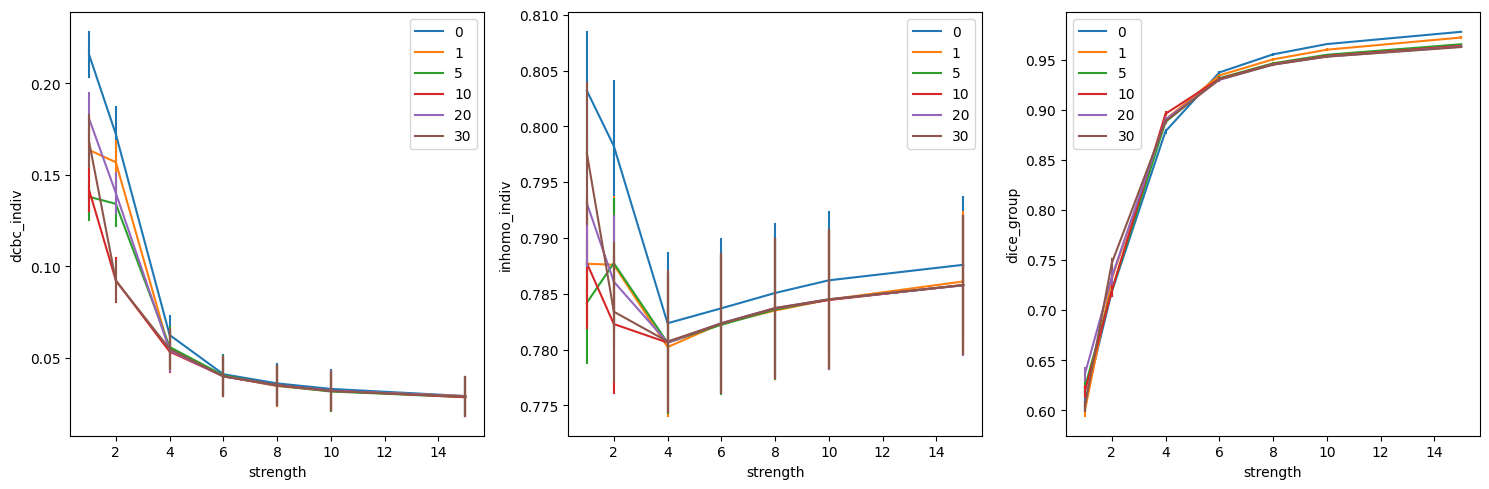

In [6]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['motor' 'mem' 'mixed' 'all']


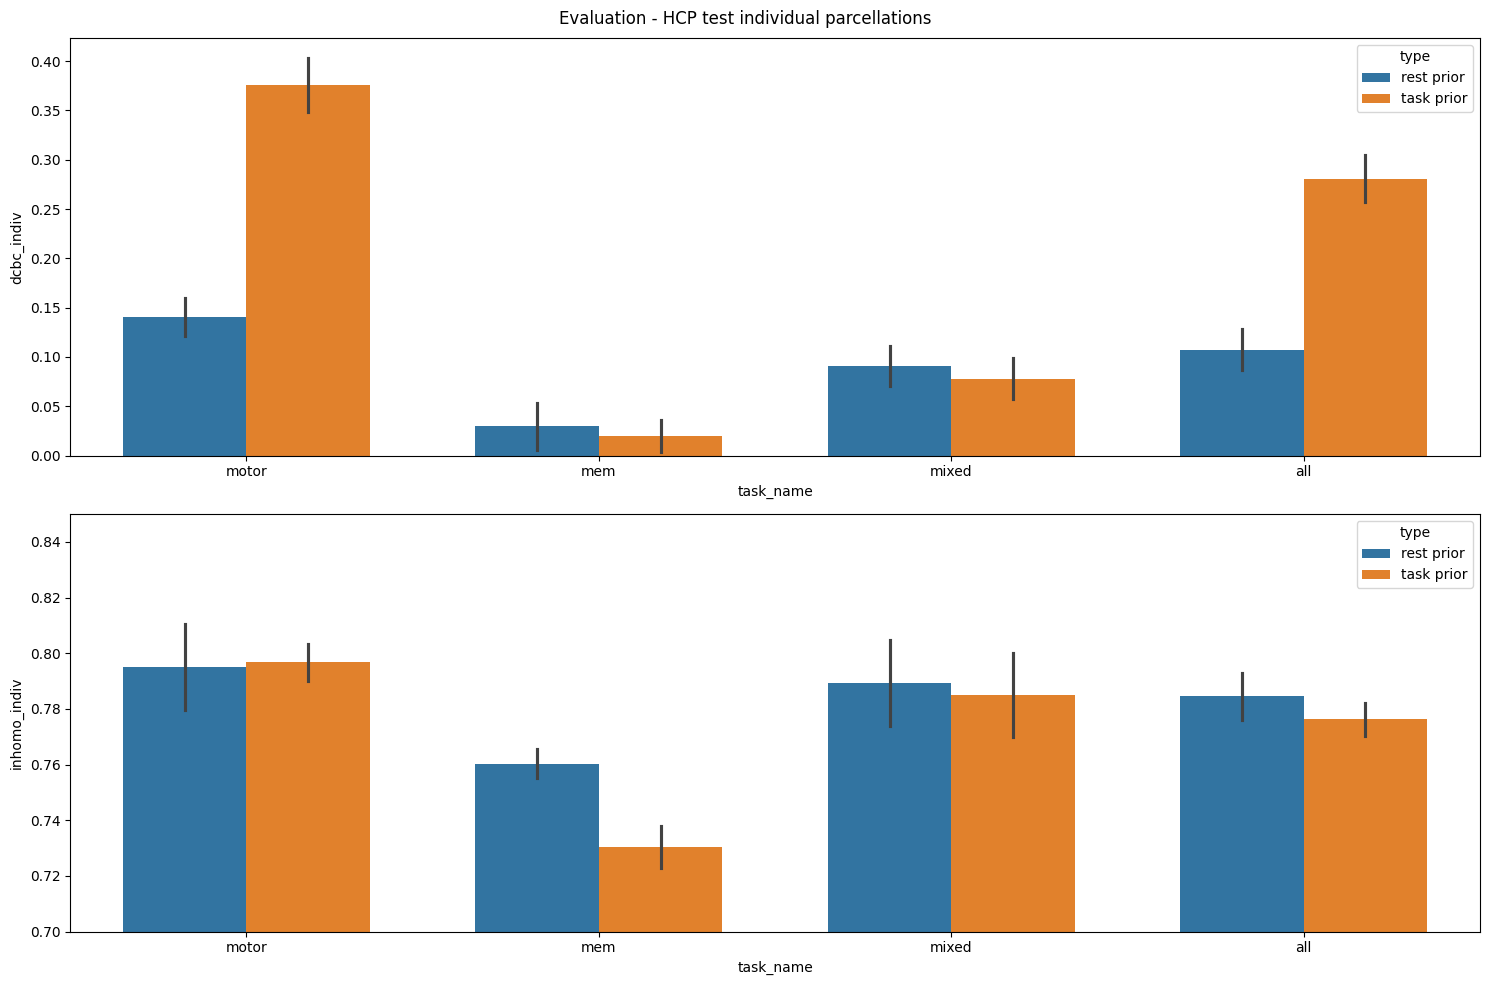

In [10]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP40+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 10)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-15_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4) & (results2['spatial_w'] == 10)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.85)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

## Control - independent model

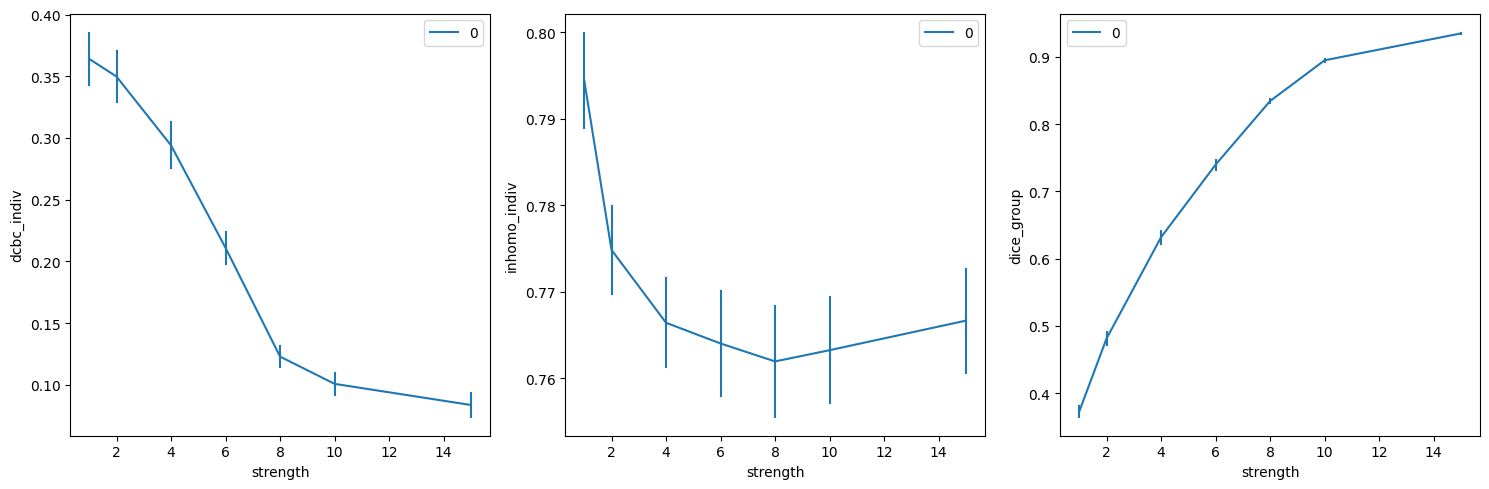

In [9]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['motor' 'mem' 'mixed' 'all']


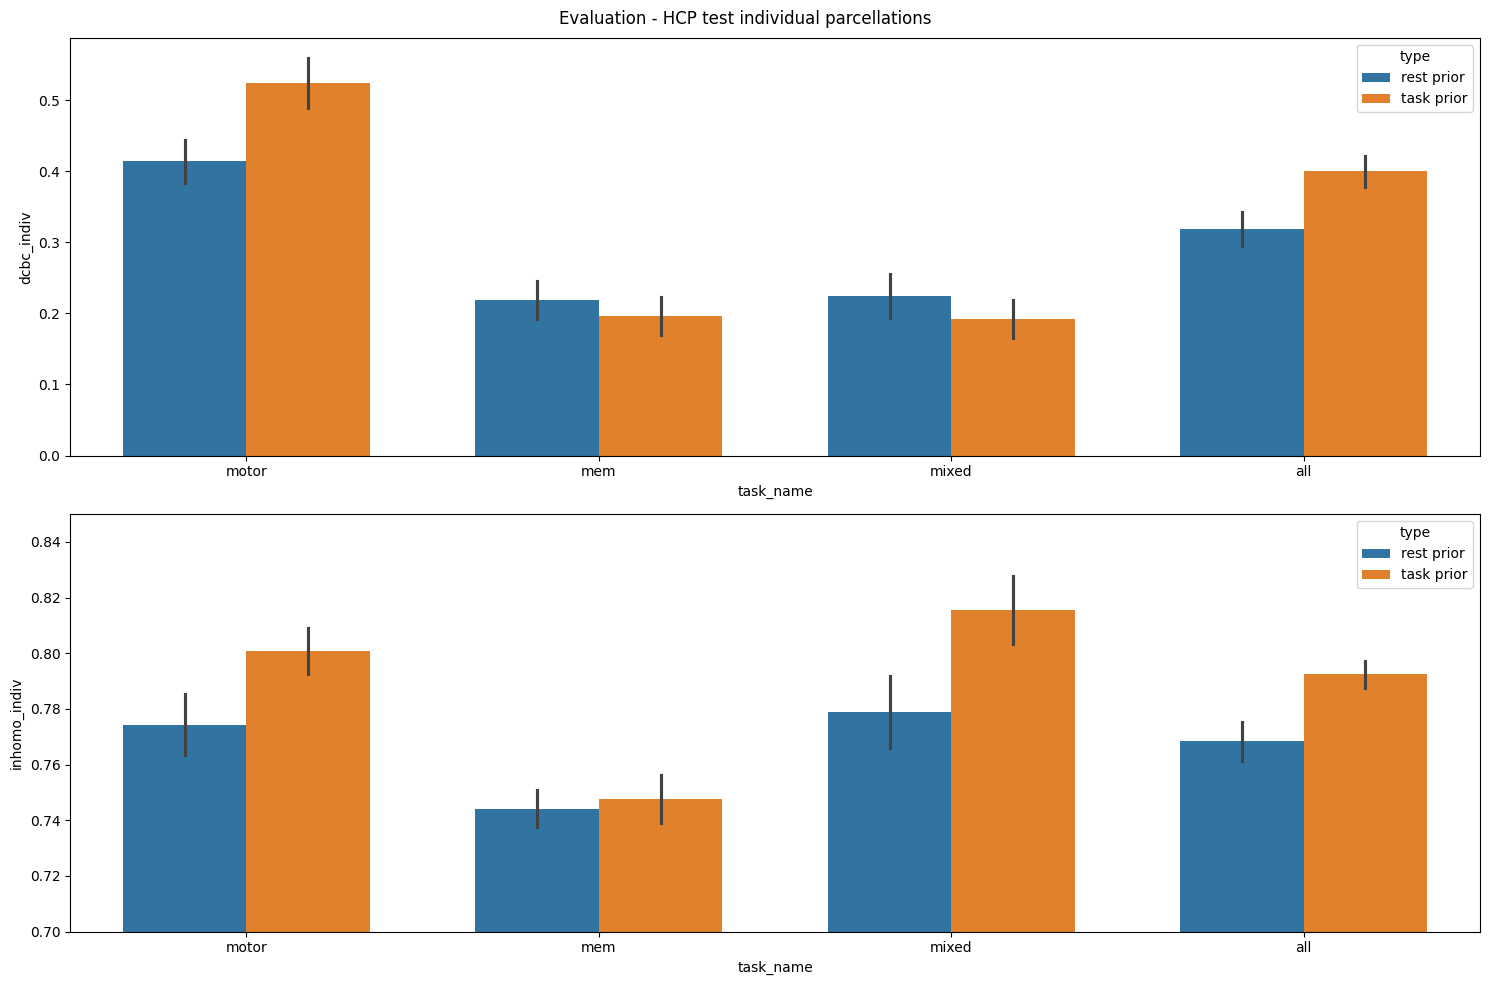

In [2]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 4)]
results1['type'] = 'rest prior'

results2 = pd.read_csv(RES_DIR + f'/eval_7taskfusion+MSCtask-half1_K-17_indiv-independent_test_on_MSCtask-half2.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 4)]
results2['type'] = 'task prior'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(2,1,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.7,0.85)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()

plt.show()

In [4]:
dat, info, _ = ds.get_dataset('/data/tge/Tian/UKBB_full/imaging', 'MDTB',
                                    atlas='fs32k', sess='ses-s1',
                                    type='CondHalf', subj=None, smooth='6fwhm_zstat_masked-hi0.1lo0.1')

# QC
import Functional_Fusion.reliability as rel
rw = rel.within_subj(np.nan_to_num(dat), cond_vec=info.cond_num, part_vec=info.half,
                     separate='condition_wise', subtract_mean=True)
cond_mask = np.where(rw <= 0.5, False, True)
cond_mask = np.hstack((cond_mask, cond_mask.copy()))
dat[~cond_mask, :] = np.nan

print(f'{np.sum(~cond_mask)}/{cond_mask.size} contrasts, drop rate {np.sum(~cond_mask)/cond_mask.size}')


172/1392 contrasts, drop rate 0.1235632183908046


the minimum reliability is 0.13091804203814925 at (np.int64(23), np.int64(21))
the minimum reliability is 0.933937967096587 at (np.int64(6), np.int64(20))


half                            1
cond_num                       22
n_rep                         8.0
instruction                     0
task_name                  stroop
cond_name             StroopIncon
task_num                       14
reg_id                         35
study                           1
cond_num_uni                   22
task_num_uni                   14
common                          0
names           StroopIncon-half1
cond_code               strpincon
sess                       ses-s1
Name: 21, dtype: object

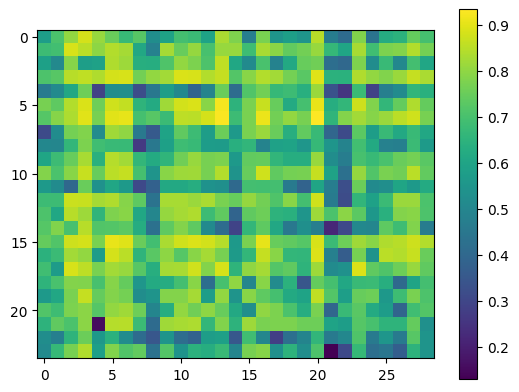

In [24]:
plt.imshow(rw)
plt.colorbar()
print(f'the minimum reliability is {np.min(rw)} at {np.unravel_index(np.argmin(rw), rw.shape)}')
print(f'the minimum reliability is {np.max(rw)} at {np.unravel_index(np.argmax(rw), rw.shape)}')
info.iloc[21]

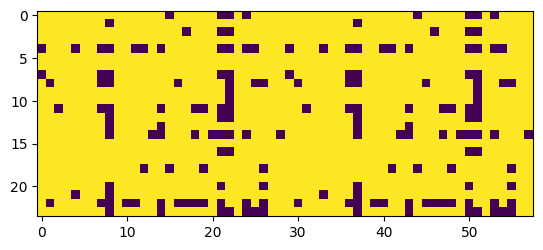

In [8]:
plt.imshow(cond_mask)

# K=17, Resting prior + individual data (pure rest, pure task, rest+task)

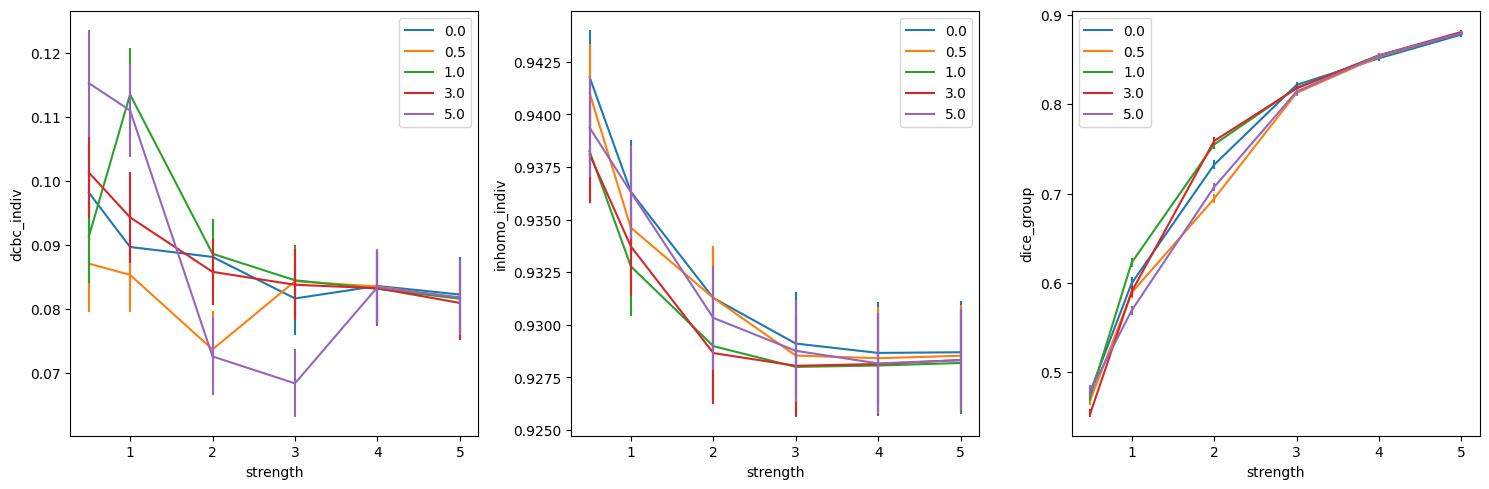

In [11]:
# eval_HCP800+HCPrest+task_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv
# eval_HCP800+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv
# eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv

results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['all']


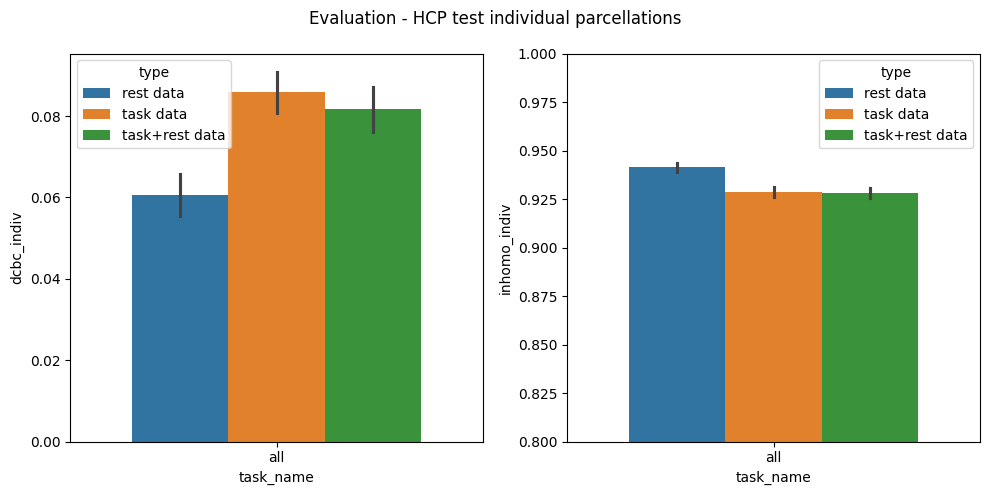

In [49]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest data'

results2 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 3)]
results2['type'] = 'task data'

results3 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest+task_K-17_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 1)]
results3['type'] = 'task+rest data'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results2, results3], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.8,1.0)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.savefig(RES_DIR + '/rest_task_k-17.pdf', format='pdf')

plt.show()

## Mean Z value

In [44]:
def plot_zvalues(input, contrast_idx, t_info, parcel_name=None):
    # Validate input
    assert input.ndim == 3, "Input tensor must be 3D: (subjects, parcels, contrasts)"
    num_subjects, num_parcels, num_contrasts = input.shape
    assert 0 <= contrast_idx < num_contrasts, "Invalid contrast index"

    # Extract the data for the given contrast
    data = input[:, :, contrast_idx]  # shape: (num_subjects, number_parcels)

    # Create parcel labels if not provided
    if parcel_name is None:
        parcel_name = [f'Parcel {i}' for i in range(num_parcels)]
    else:
        assert len(parcel_name) == num_parcels, 'Invalid parcel names'

    # Create DataFrame for plotting
    df = pd.DataFrame()        
    for i in range(num_parcels):
        this_df = pd.DataFrame({'subject': np.arange(num_subjects),
            'parcel': parcel_name[i],
            'z_value': data[:,i],
            'domain': t_info.iloc[contrast_idx].task_name
        })
        df = pd.concat([df, this_df], ignore_index=True)

    df['contrast_name'] = t_info.iloc[contrast_idx].contrast_name

    return df

In [4]:
import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
HCP_DIR = '/data/tge/Tian/HCP_img'

align, net_name, colors = get_kong2019_17_parcellation()
t_data, t_info = load_hcp_contrasts(HCP_DIR, "/subj_list/HCP203_test_set_filtered_1.tsv", space='fs32k',
                                    hemis='L', smooth='4_MSMAll')
pd.set_option('display.max_rows', None)
t_info

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-

,contrast_name,task_name
0,FACES-SHAPES_hp200_s4_MSMAll,EMOTION
1,neg_FACES_hp200_s4_MSMAll,EMOTION
2,neg_SHAPES_hp200_s4_MSMAll,EMOTION
3,SHAPES-FACES_hp200_s4_MSMAll,EMOTION
4,PUNISH-REWARD_hp200_s4_MSMAll,GAMBLING
5,neg_PUNISH_hp200_s4_MSMAll,GAMBLING
6,neg_REWARD_hp200_s4_MSMAll,GAMBLING
7,REWARD-PUNISH_hp200_s4_MSMAll,GAMBLING
8,MATH-STORY_hp200_s4_MSMAll,LANGUAGE
9,STORY-MATH_hp200_s4_MSMAll,LANGUAGE


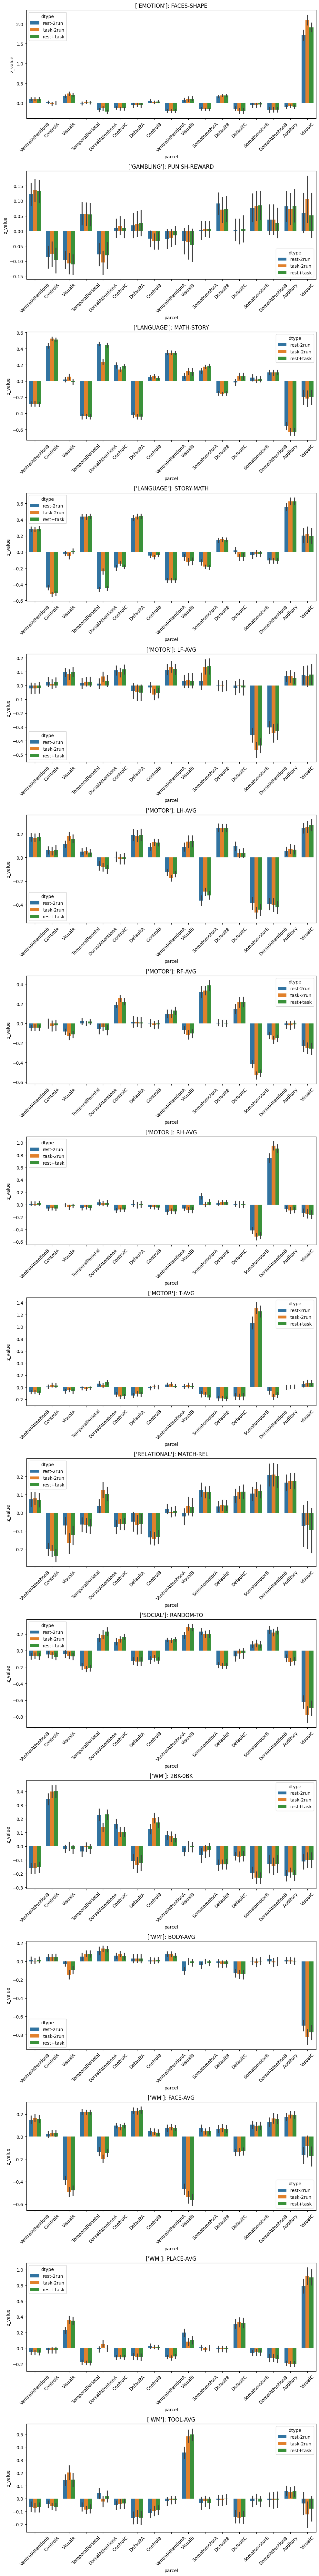

In [28]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
res1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest-2run-indiv_K-17_strengh-2_spatial-5.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPtask-2run-indiv_K-17_strengh-2_spatial-3.npy')

res3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest+task-indiv_K-17_strengh-2_spatial-1.npy')

df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in [0,4,8,9,14,15,16,17,18,32,36,42,50,51,52,53]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

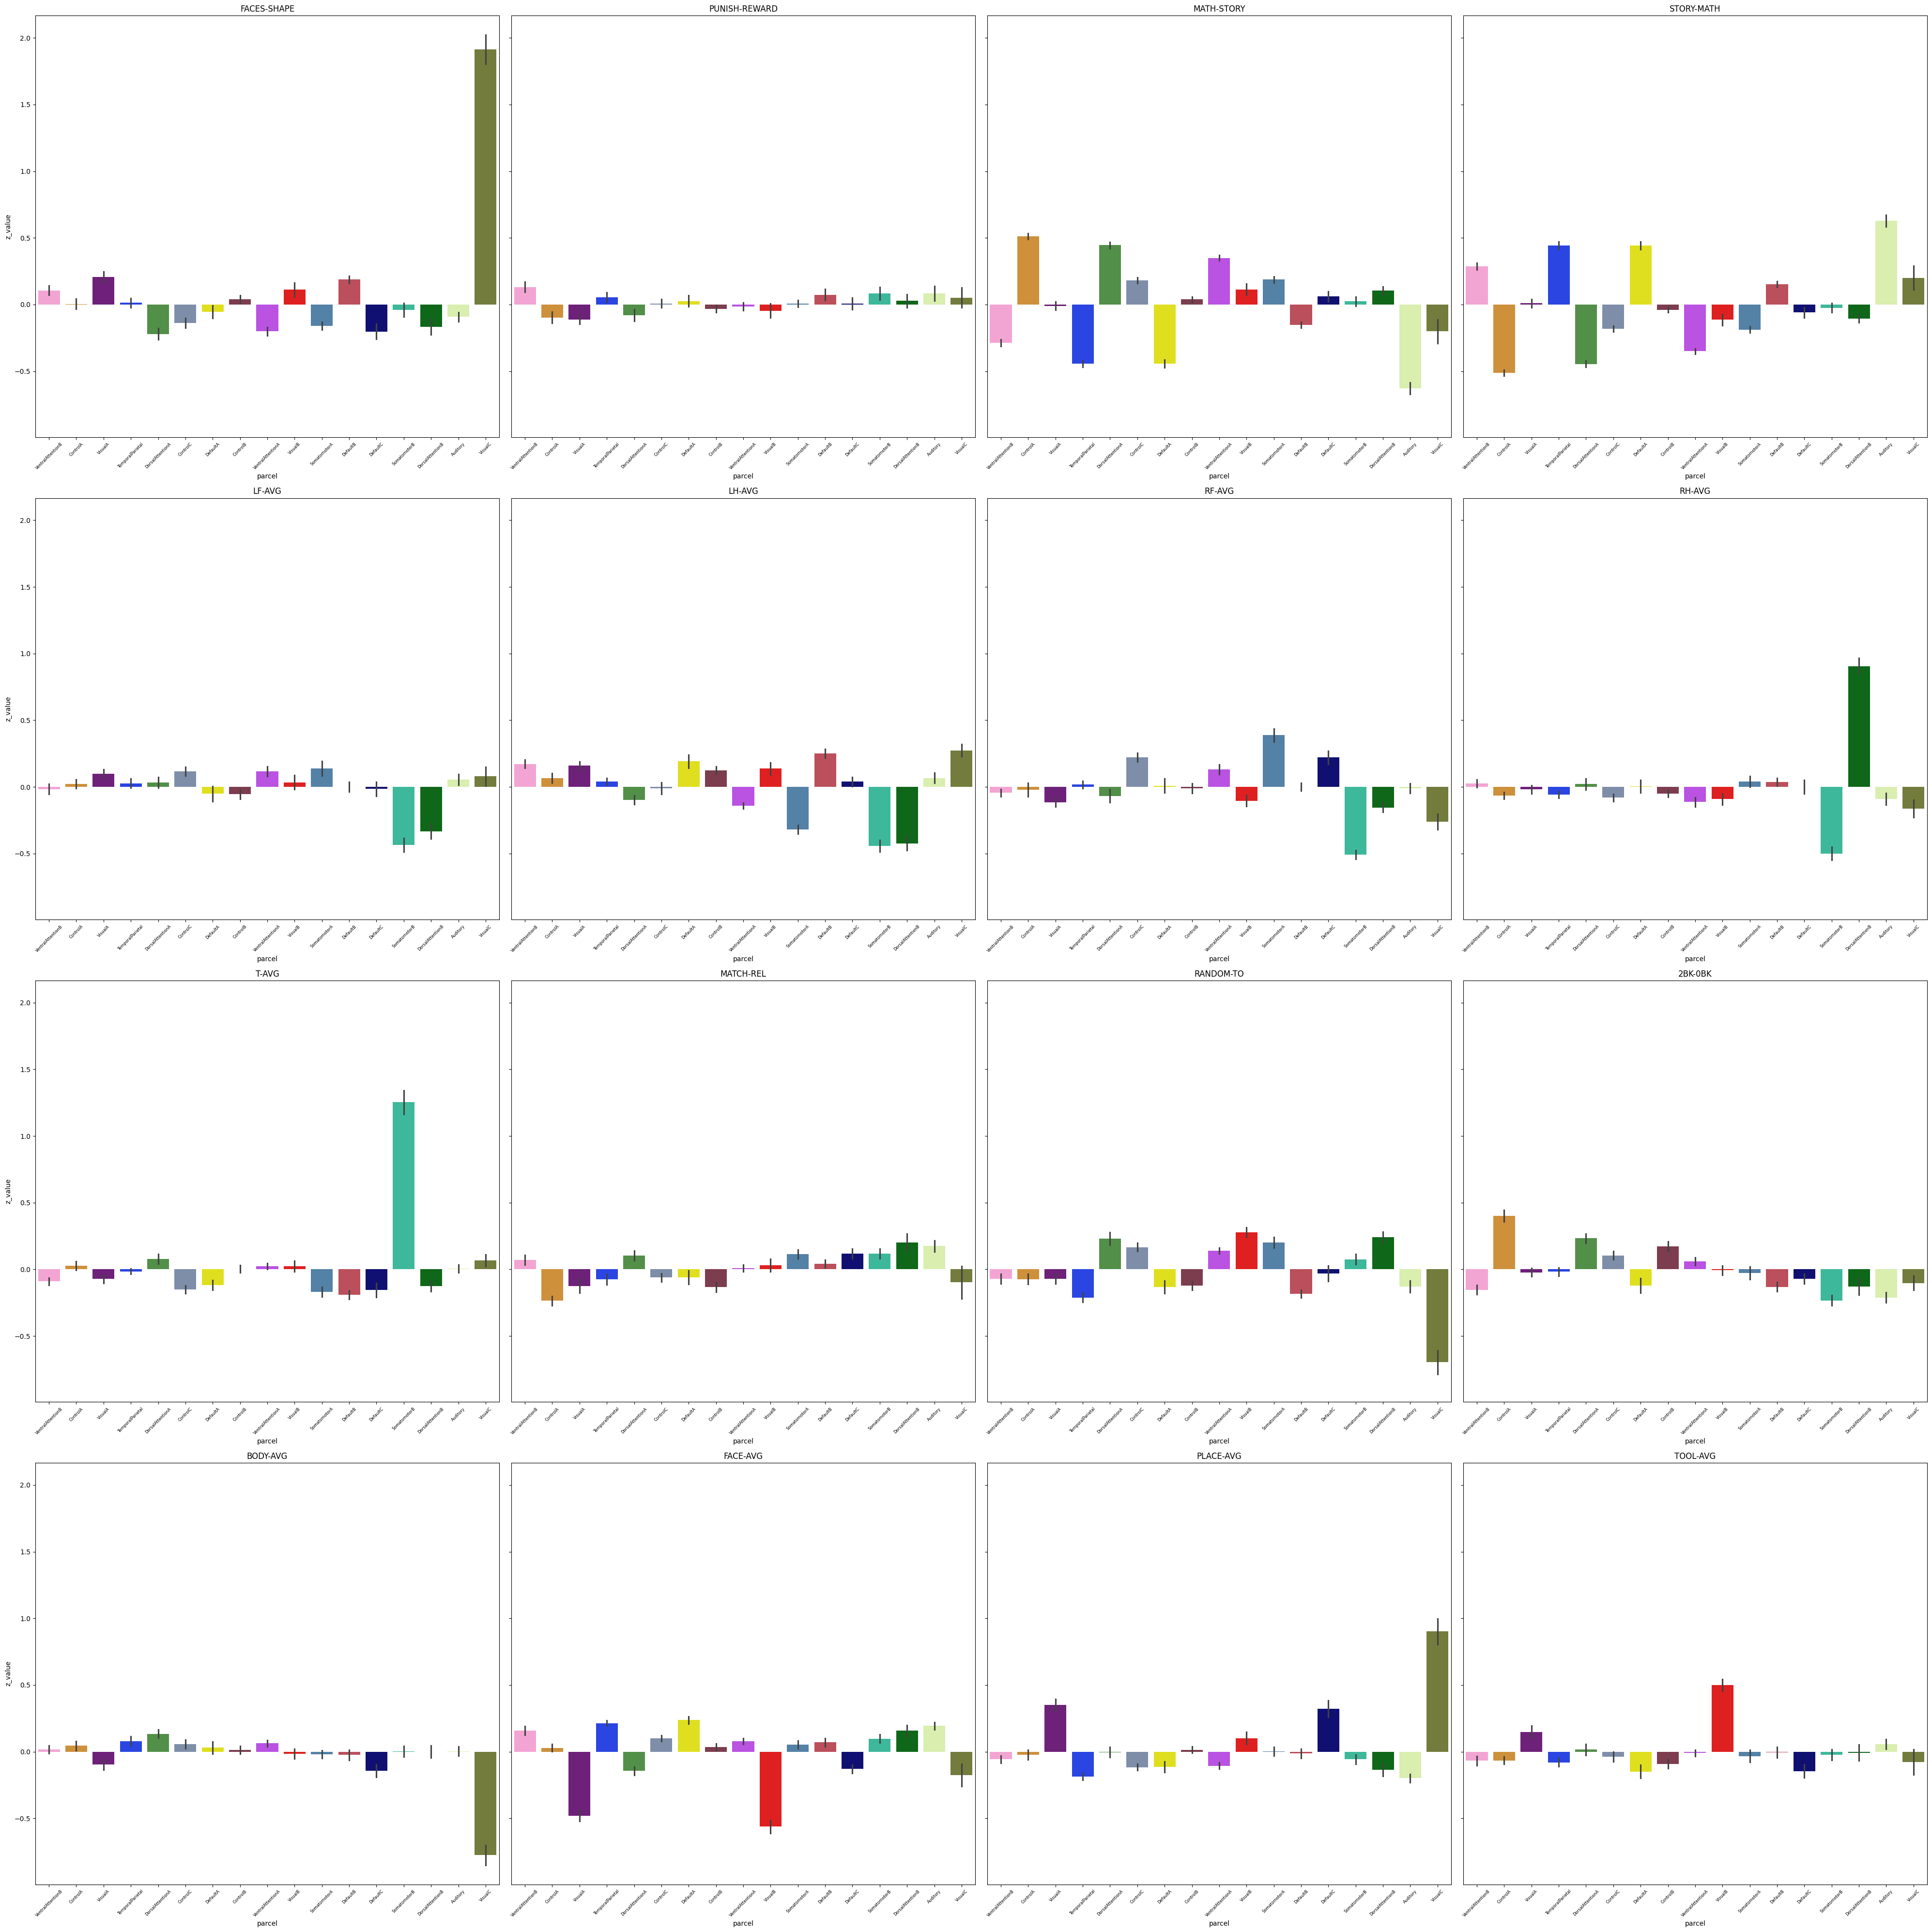

In [19]:
color_list = [tuple(color) for color in colors[1:,:]]

num_contrasts = df_all["contrast_name"].unique()
rows, cols = 4, 4
fig, axes = plt.subplots(rows, cols, figsize=(40, 40), sharey=True)
axes = axes.flatten()

for i, contrast_idx in enumerate(num_contrasts):
    ax = axes[i]
    sub_df = df_all[(df_all["contrast_name"] == contrast_idx) & (df_all["dtype"] == 'rest+task')]
    sb.barplot(data=sub_df, x='parcel', y='z_value', errorbar='se', palette=color_list, ax=ax)
    ax.set_title(f'{contrast_idx}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=6)

# Turn off unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# K=15, HCP40 Resting prior + individual data (pure rest, pure task, rest+task)

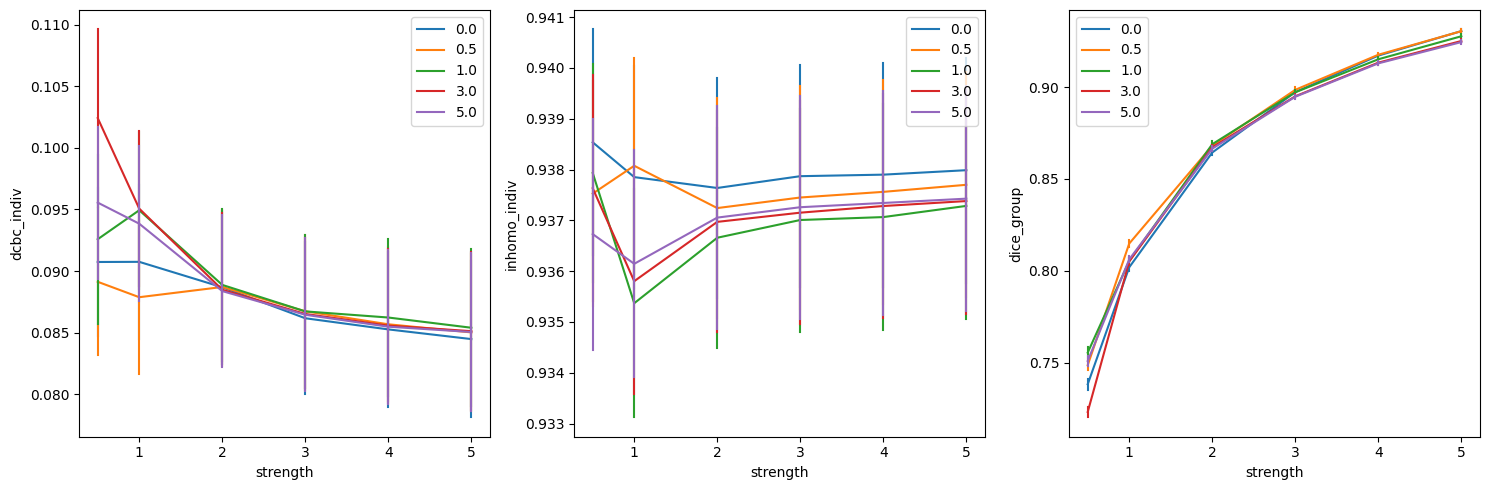

In [35]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP800+HCPrest+task_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,2)
sb.lineplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,3,3)
sb.lineplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

['all']


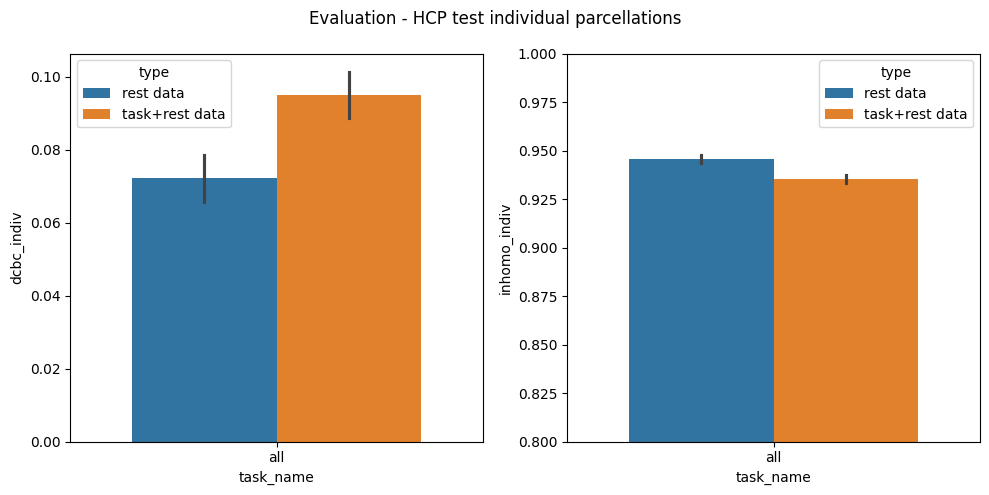

In [8]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'

results1 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest-2run_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results1 = results1.loc[(results1['strength'] == 2) & (results1['spatial_w'] == 5)]
results1['type'] = 'rest data'

results2 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPtask-2run_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results2 = results2.loc[(results2['strength'] == 2) & (results2['spatial_w'] == 1)]
results2['type'] = 'task data'

results3 = pd.read_csv(RES_DIR + f'/eval_HCP800+HCPrest+task_K-15_indiv-mRBM_test_on_HCPtask-contrast.tsv', sep='\t')
results3 = results3.loc[(results3['strength'] == 1) & (results3['spatial_w'] == 1)]
results3['type'] = 'task+rest data'

# results3 = pd.read_csv(RES_DIR + f'/eval_KONG2019+MSCtask-half1_K-17_indiv-WcRBM_test_on_MSCtask-half2.tsv', sep='\t')
# results3 = results3.loc[(results3['strength'] == 2) & (results3['spatial_w'] == 5)]
# results3['type'] = 'Kong 2019 prior'

results = pd.concat([results1, results3], ignore_index=True)
print(results.task_name.unique())

# Plot results
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
# sb.boxplot(data=results, x='network', y='dice', hue='type', width=0.7)
sb.barplot(data=results, x='task_name', y='dcbc_indiv', hue='type', errorbar='se', width=0.7)

plt.subplot(1,2,2)
sb.barplot(data=results, x='task_name', y='inhomo_indiv', hue='type', errorbar='se', width=0.7)
plt.ylim(0.8,1.0)

plt.suptitle('Evaluation - HCP test individual parcellations')
plt.tight_layout()
plt.savefig(RES_DIR + '/rest_task_k-15.pdf', format='pdf')
plt.show()

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


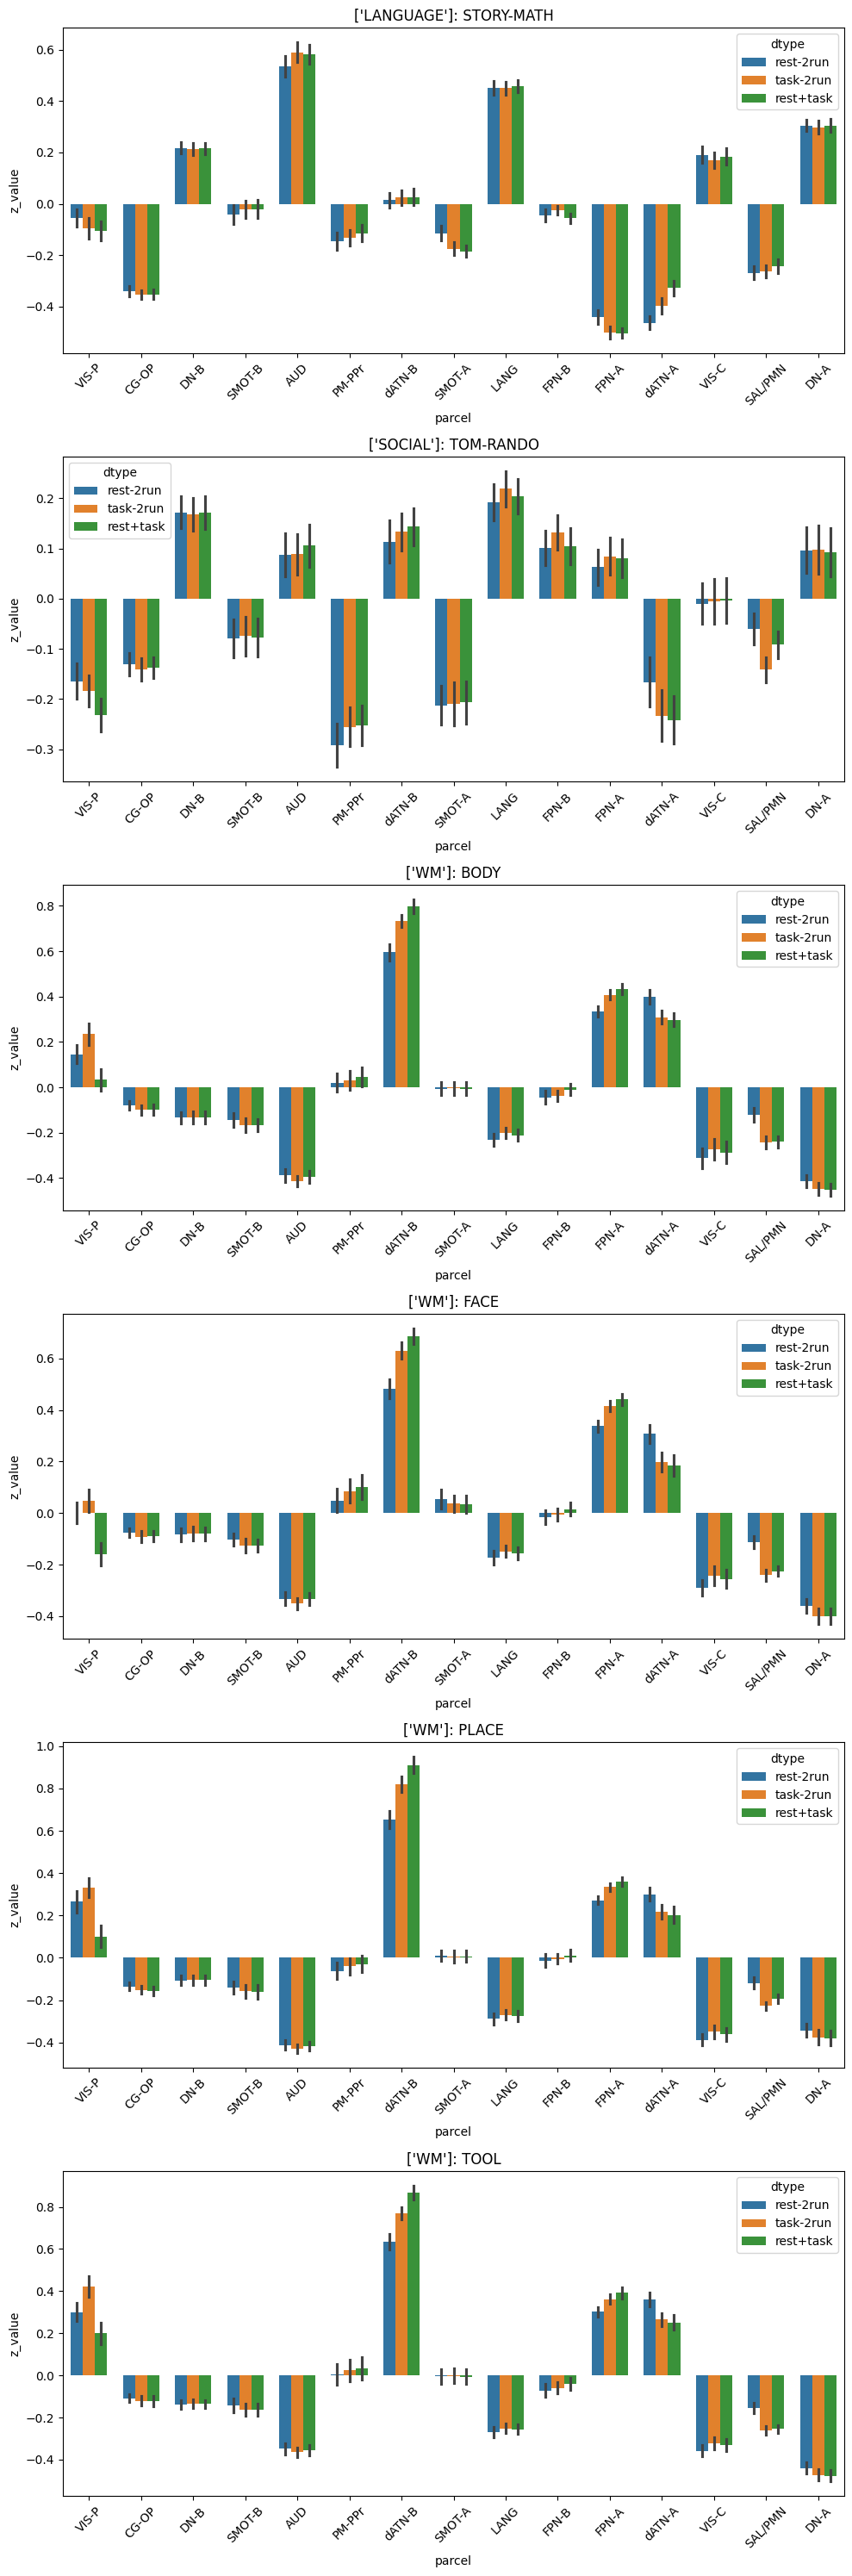

In [33]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
res1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest-2run-indiv_K-15_strengh-2_spatial-5.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPtask-2run-indiv_K-15_strengh-2_spatial-1.npy')

res3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP800+HCPrest+task-indiv_K-15_strengh-1_spatial-1.npy')

DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')
df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in [9,39,46,47,48,49]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

# K=15, RANDY15 Resting prior + individual resting-state data

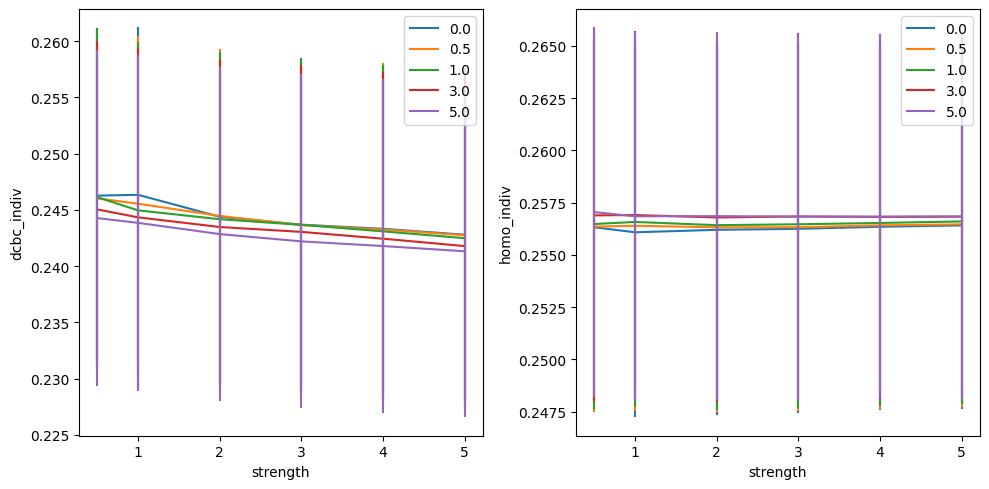

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_HCP40+RANDYrest-5run_indiv_k-15_test_on_RANDYrest_Tseries.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.lineplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.subplot(1,2,2)
sb.lineplot(data=results, x="strength", y='homo_indiv', hue='spatial_w', errorbar="se", palette='tab10',
            err_style="bars", markers=True, markersize=10)
plt.legend()

plt.tight_layout()
plt.show()

## Z values

In [45]:
import sys
sys.path.append('/PHShome/dz010/Workspace/IndividualParcellation/scripts')

from IndividualParcellation.scripts.indiv_eval_hcp import *
HCP_DIR = '/data/tge/Tian/HCP_img'

# align, net_name, colors = get_kong2019_17_parcellation()
DU15, net_name, colors = gp.get_DU15_parcellation(file_name='DU15NET_Prior', atlas_space='fs32k')

t_data, t_info = ut.load_randy_contrasts(subj=None, hemis='L', smooth=2)
pd.set_option('display.max_rows', None)
t_info['task_name'] = t_info['domain']
t_info

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


,sn,cond_id,contrast_name,domain,task_name
0,sub-02,1,PASTFUTUREmPRESENT,Episodic_Projection,Episodic_Projection
1,sub-02,2,GLUTESmALL,Motor,Motor
2,sub-02,3,RFOOTmLFOOT,Motor,Motor
3,sub-02,4,RHANDmLHAND,Motor,Motor
4,sub-02,5,TONGUEmALL,Motor,Motor
5,sub-02,6,2BACKm0BACK_ALL,N-Back,N-Back
6,sub-02,7,2BACKm0BACK_FACE,N-Back,N-Back
7,sub-02,8,2BACKm0BACK_LETTER,N-Back,N-Back
8,sub-02,9,2BACKm0BACK_RHYME,N-Back,N-Back
9,sub-02,10,2BACKm0BACK_SCENE,N-Back,N-Back


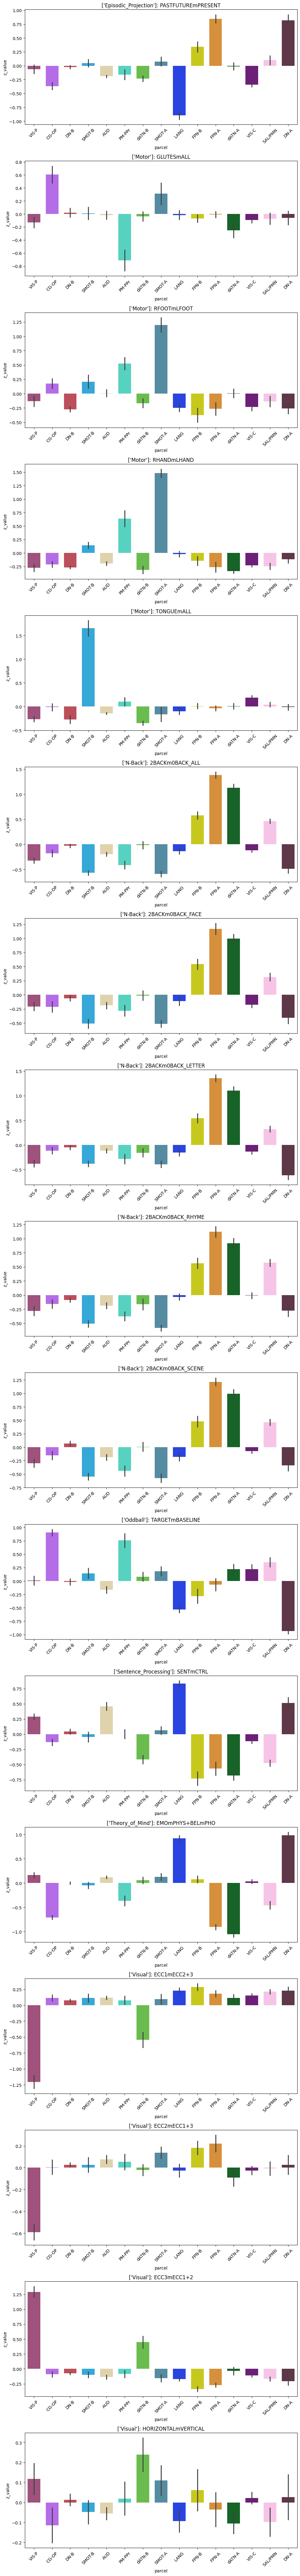

In [10]:
d_type = ['rest-2run', 'task-2run', 'rest+task']
color_list = [tuple(color) for color in colors[1:,:]]

res = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_HCP40+RANDYrest-5run-indiv_K-15_strengh-1_spatial-0.npy')

df_all = pd.DataFrame()
for i in range(17):
    df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
    df_all = pd.concat([df_all, df], ignore_index=True)

con_nam = df_all['contrast_name'].unique()
plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', errorbar='se', palette=color_list, width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

## Compare MSHBM vs. HBP using the same KONG2019 group prior (HCP203 filtered 1)

[30 15  0  1  2  5  8 10]


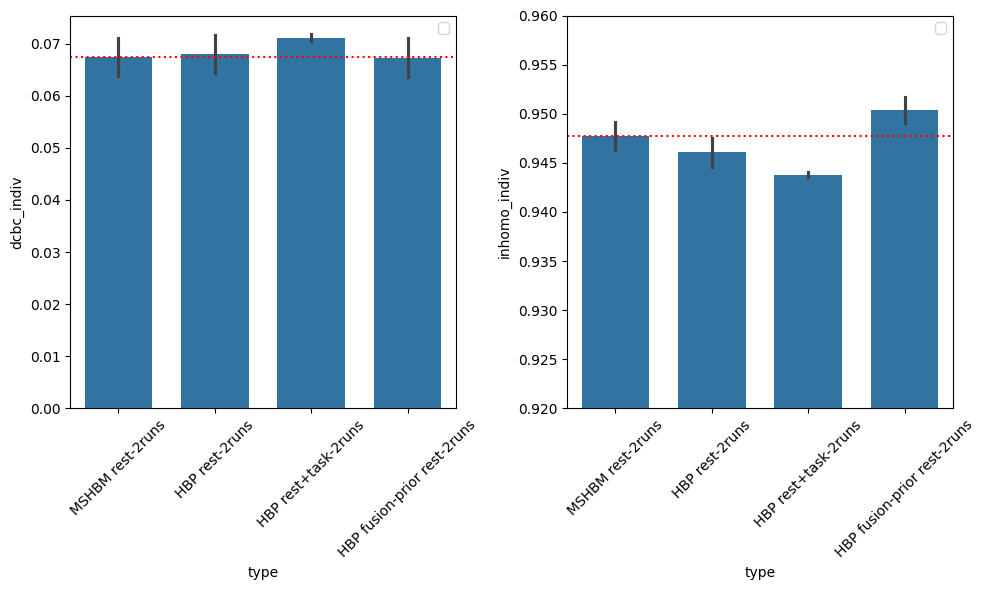

In [4]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1_add.tsv', sep='\t')
results = pd.concat([res1, res2], ignore_index=True)
kong_indiv = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCPrest-2run_K-17_indiv_test_on_HCPtask-contrast_1.tsv', sep='\t')
kong_indiv['type'] = 'MSHBM rest-2runs'
results = results.loc[(results['strength'] == 80) & (results['spatial_w'] == 15)]
results['type'] = 'HBP rest-2runs'
# results["spatial_w"] = results["spatial_w"].astype(str)

res3 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest+task-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
res3['type'] = 'HBP rest+task-2runs'

res4 = pd.read_csv('/data/tge/dzhi/Indiv_par/Evaluations/eval_MdNiIbHc+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
res4 = res4.loc[(res4['strength'] == 20) & (res4['spatial_w'] == 10)]
res4['type'] = 'HBP fusion-prior rest-2runs'

results = pd.concat([kong_indiv, results,res3, res4], ignore_index=True)

print(results.spatial_w.unique())
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="type", y='dcbc_indiv', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.dcbc_indiv.mean(), color='r', linestyle=':')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="type", y='inhomo_indiv', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.inhomo_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.92, 0.96)
plt.xticks(rotation=45)
plt.legend()

# plt.subplot(3,1,3)
# sb.barplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", width=0.7)
# plt.legend()

plt.tight_layout()
plt.show()

['0' '1' '2' '5' '8' '10' '15']


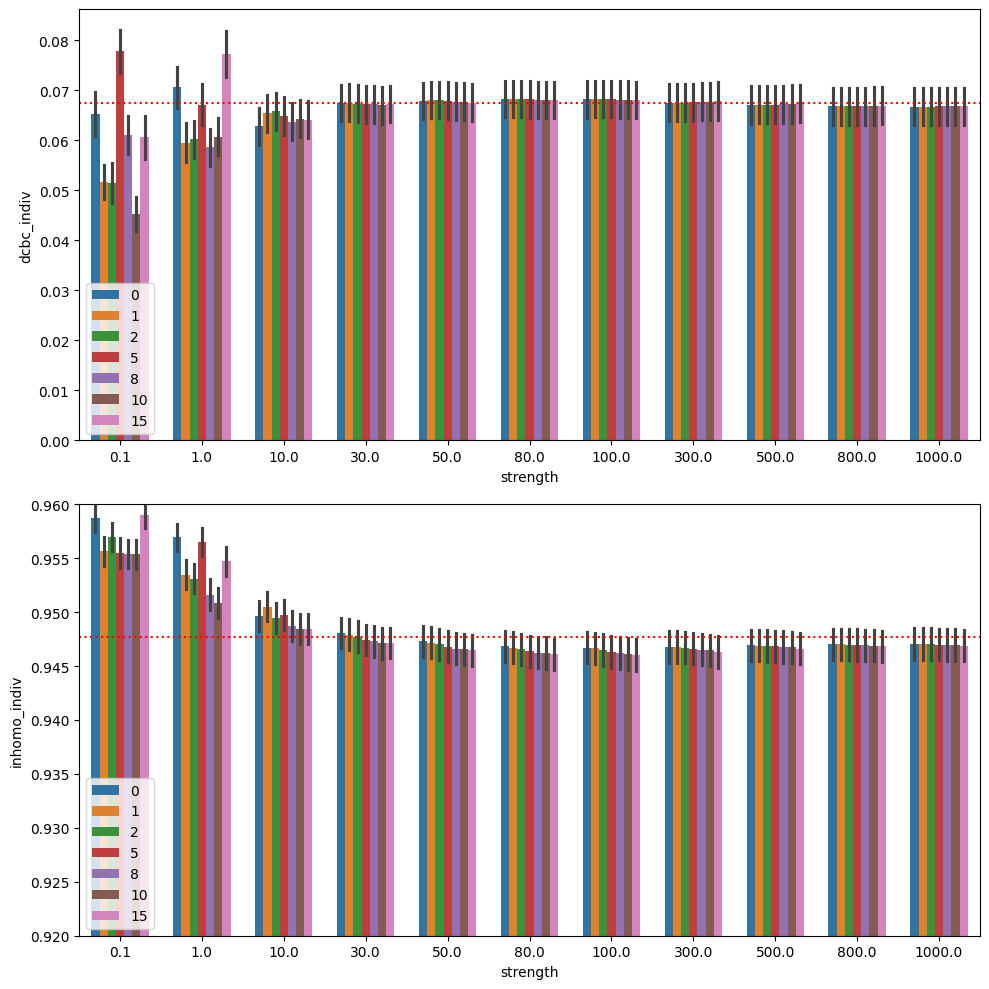

In [9]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1_add.tsv', sep='\t')
results = pd.concat([res1, res2], ignore_index=True)

# results = pd.read_csv('/data/tge/dzhi/Indiv_par/Evaluations/eval_MdNiIbHc+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
kong_indiv = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCPrest-2run_K-17_indiv_test_on_HCPtask-contrast_1.tsv', sep='\t')

# results = results.loc[(results['strength'] == 80) & (results['spatial_w'] == 15)]\
results["spatial_w"] = results["spatial_w"].astype(str)
print(results.spatial_w.unique())

plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
sb.barplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.dcbc_indiv.mean(), color='r', linestyle=':')
plt.legend()

plt.subplot(2,1,2)
sb.barplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.inhomo_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.92, 0.96)
plt.legend()

# plt.subplot(3,1,3)
# sb.barplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", width=0.7)
# plt.legend()

plt.tight_layout()
plt.show()

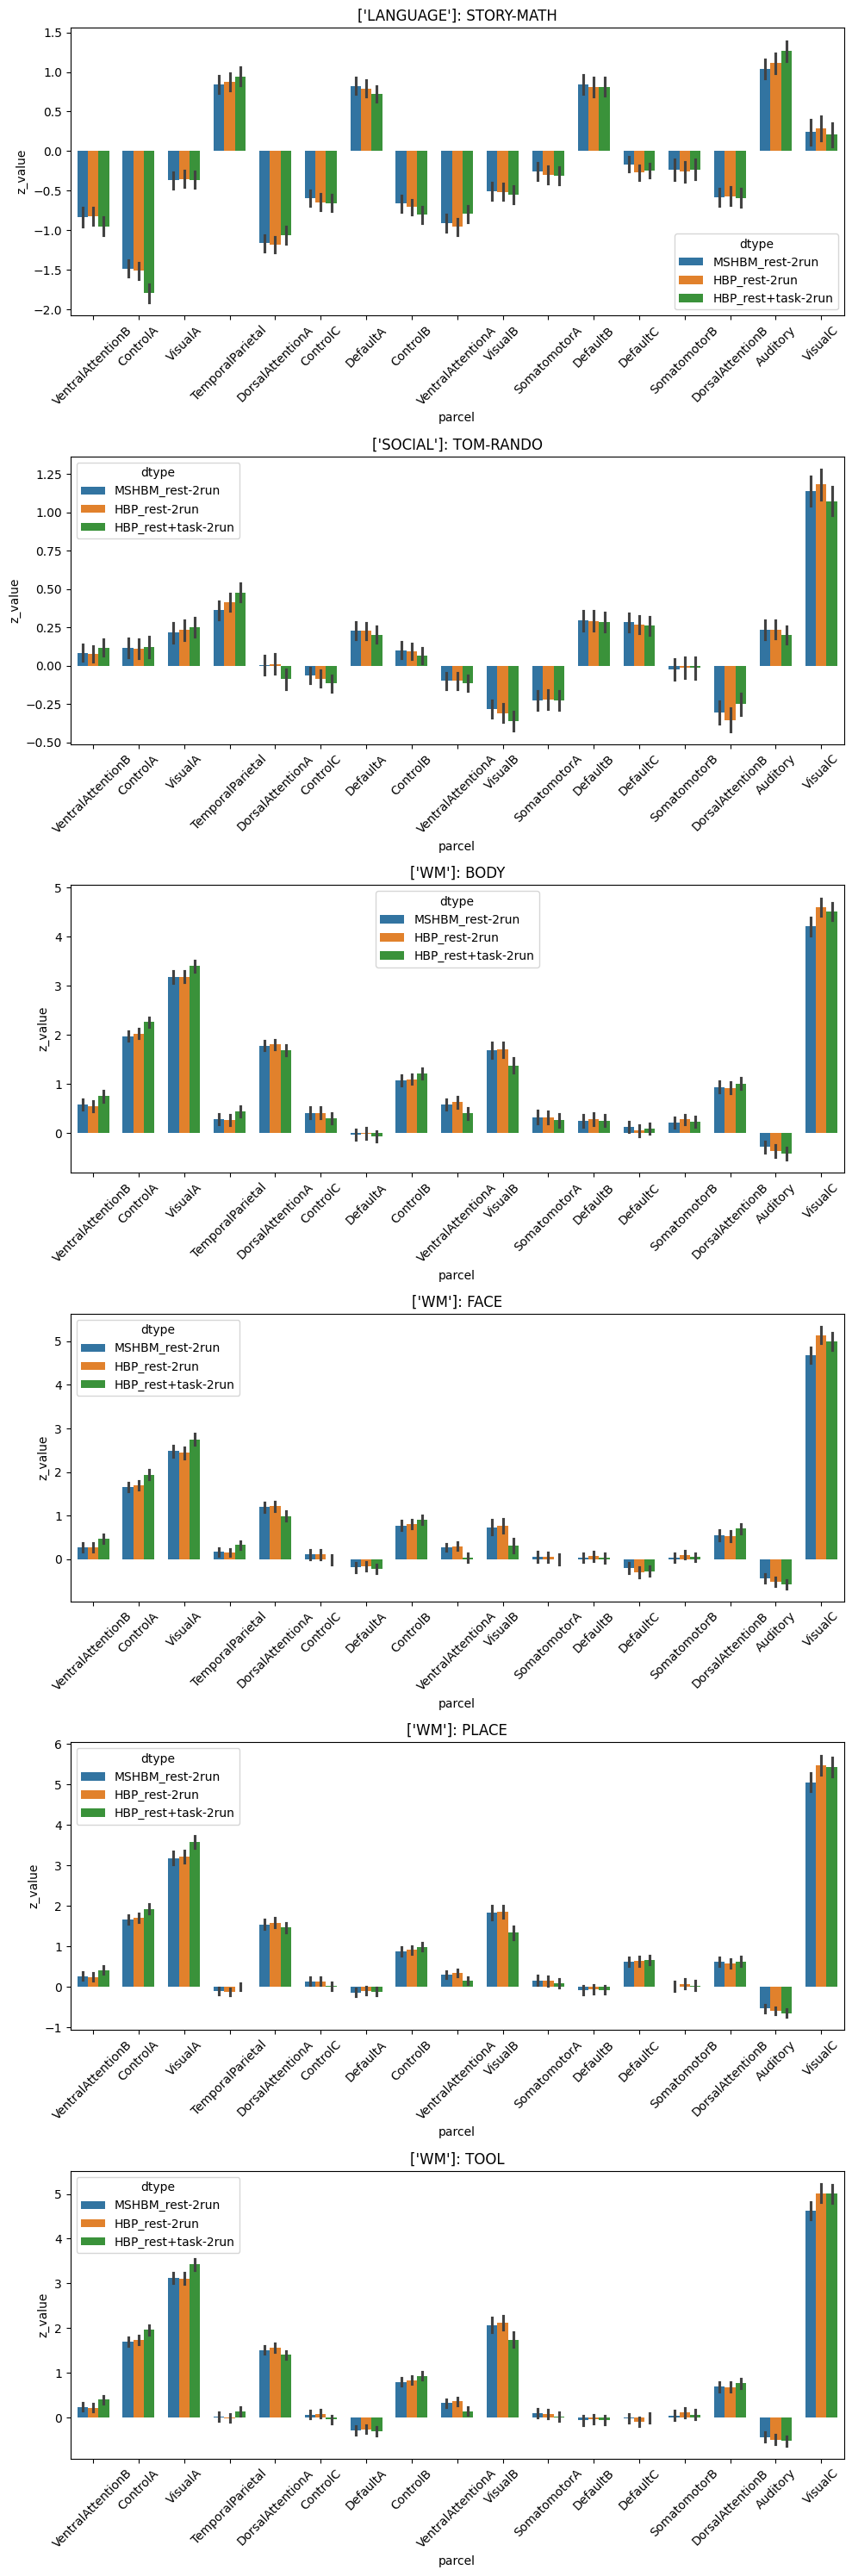

In [37]:
d_type = ['MSHBM_rest-2run', 'HBP_rest-2run', 'HBP_rest+task-2run']
res1 = np.load(f'/data/tge/dzhi/workspace/res/ind_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_MSHBM+HCPrest-2run-indiv_K-17_w100_MRF30_1.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_KONG2019+HCPrest-2run-indiv_K-17_strengh-80_spatial-15_1.npy')

res3 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_KONG2019+HCPrest+task-2run-indiv_K-17_strengh-1_spatial-1_1.npy')

kong2019, net_name, colors = get_kong2019_17_parcellation()
df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in [9,39,46,47,48,49]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

['0' '1' '2' '5' '8' '10' '15']


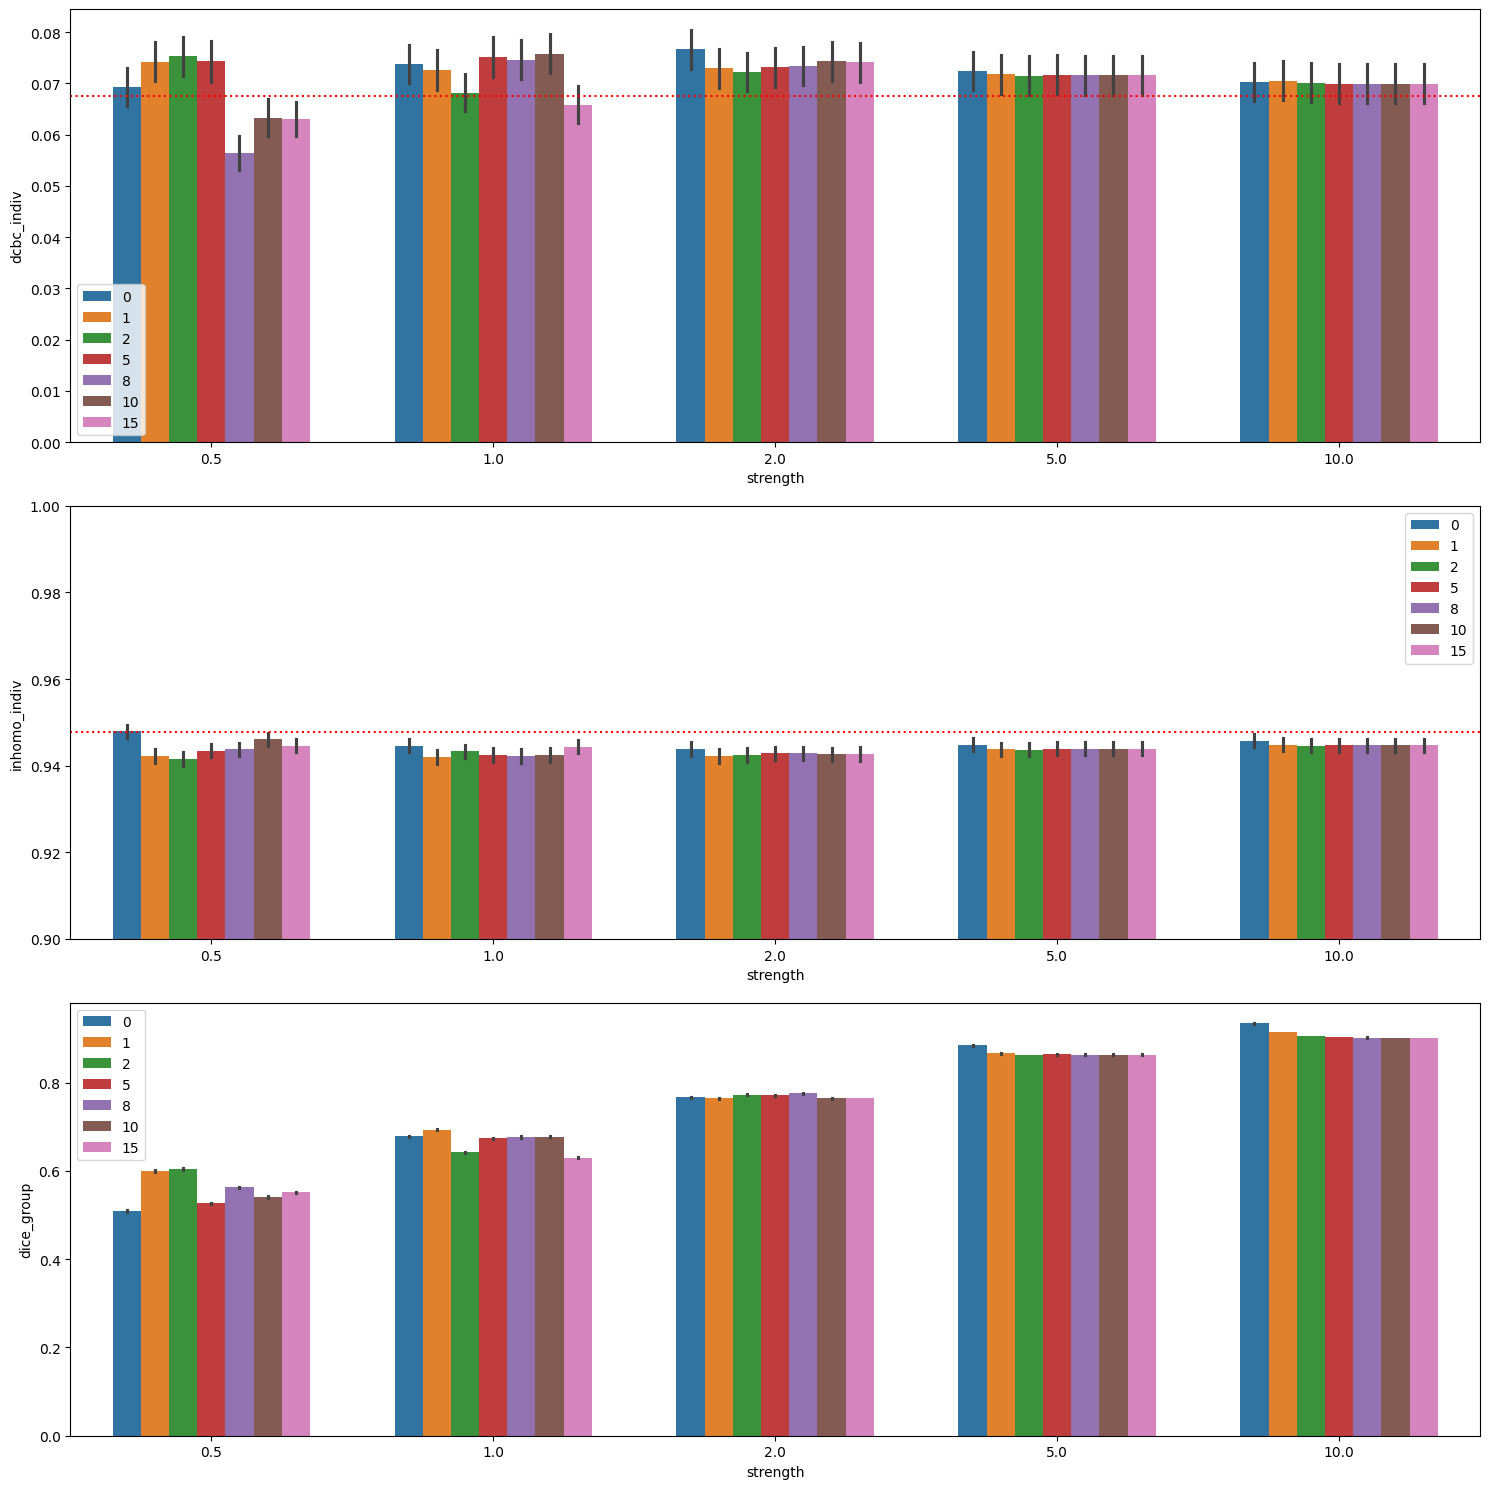

In [3]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest+task-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_1.tsv', sep='\t')
kong_indiv = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCPrest-2run_K-17_indiv_test_on_HCPtask-contrast_1.tsv', sep='\t')
results["spatial_w"] = results["spatial_w"].astype(str)

print(results.spatial_w.unique())
plt.figure(figsize=(15,15))
plt.subplot(3,1,1)
sb.barplot(data=results, x="strength", y='dcbc_indiv', hue='spatial_w', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.dcbc_indiv.mean(), color='r', linestyle=':')
plt.legend()

plt.subplot(3,1,2)
sb.barplot(data=results, x="strength", y='inhomo_indiv', hue='spatial_w', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.inhomo_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.9, 1)
plt.legend()

plt.subplot(3,1,3)
sb.barplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", width=0.7)
plt.legend()

plt.tight_layout()
plt.show()

## Group prior comparison (rest vs. task vs. fusion)

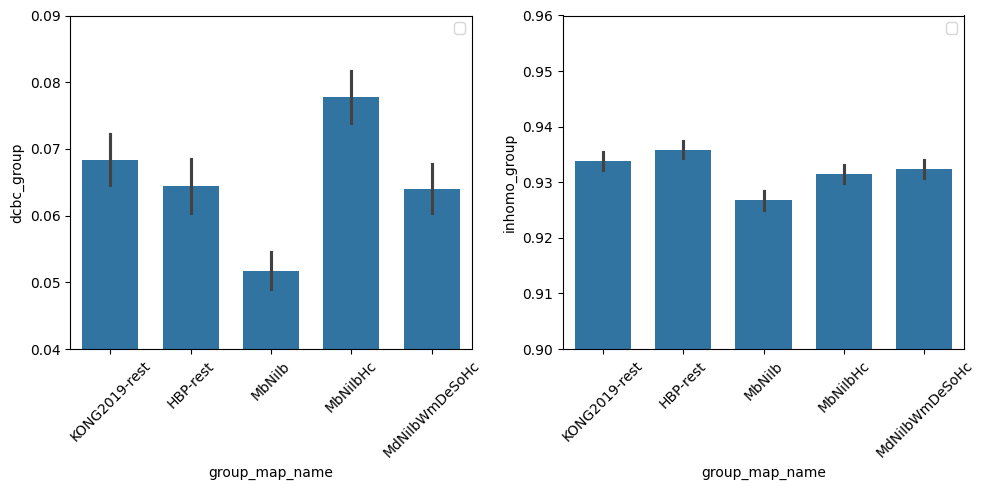

In [20]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group_rest_vs_task_vs_fusion_K-17_on-HCP-contrasts.tsv', sep='\t')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se", width=0.7)
plt.ylim(0.04, 0.09)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_group', errorbar="se", width=0.7)
plt.ylim(0.9, 0.96)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Individual comaprison (pure rest prior vs. fusion prior) on HCP 2 runs rs-fMRI

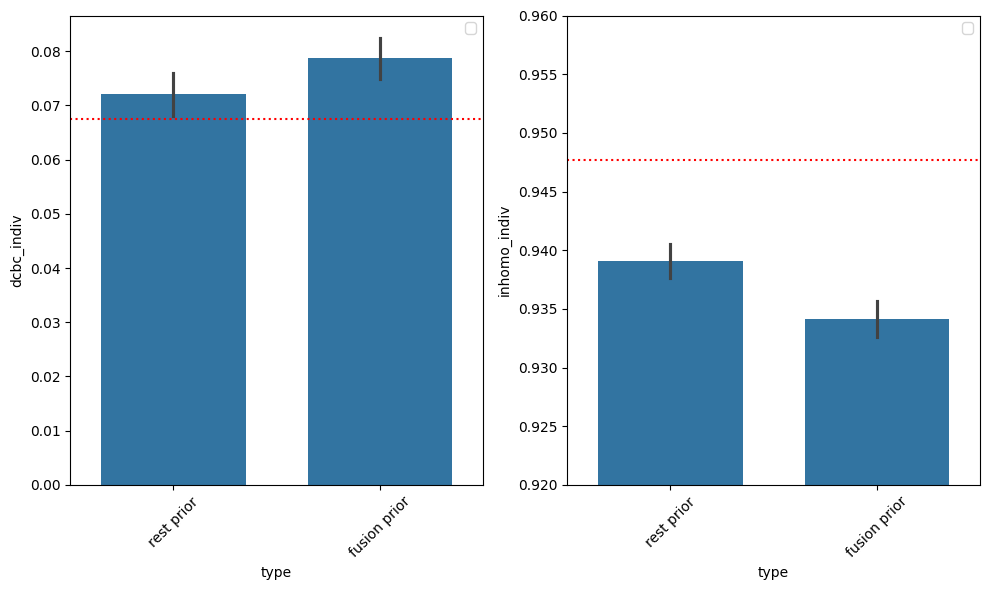

TtestResult(statistic=np.float64(-5.639082828370117), pvalue=np.float64(8.378384321556156e-07), df=np.int64(49))
TtestResult(statistic=np.float64(20.052892184905335), pvalue=np.float64(2.872410906818934e-25), df=np.int64(49))


In [13]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdNiIbHc+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_sm4_1.tsv', sep='\t')
res1 = res1.loc[(res1['strength'] == 20) & (res1['spatial_w'] == 5)]
res1['type'] = 'fusion prior'

res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast_sm4_1.tsv', sep='\t')
res2 = res2.loc[(res2['strength'] == 10) & (res2['spatial_w'] == 5)]
res2['type'] = 'rest prior'

results = pd.concat([res2, res1], ignore_index=True)
kong_indiv = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM-HCPrest-2run_K-17_indiv_test_on_HCPtask-contrast_1.tsv', sep='\t')
kong_indiv['type'] = 'MSHBM rest-2runs'

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sb.barplot(data=results, x="type", y='dcbc_indiv', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.dcbc_indiv.mean(), color='r', linestyle=':')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="type", y='inhomo_indiv', errorbar="se", width=0.7)
plt.axhline(y=kong_indiv.inhomo_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.92, 0.96)
plt.xticks(rotation=45)
plt.legend()

# plt.subplot(3,1,3)
# sb.barplot(data=results, x="strength", y='dice_group', hue='spatial_w', errorbar="se", width=0.7)
# plt.legend()

plt.tight_layout()
plt.show()

from scipy import stats
a = results.loc[results.type == 'rest prior']
b = results.loc[results.type == 'fusion prior']

print(stats.ttest_rel(a.dcbc_indiv, b.dcbc_indiv))
print(stats.ttest_rel(a.inhomo_indiv, b.inhomo_indiv))

## Mean Z-values

1. (Not sure) EMOTION: FACE-SHAPE (index:0)  (Dorsal Attention A/B?)
2. (NOt sure) GAMBLING: REWARD-PUNISH (index:7) (FPN-A / Control A)
3. LANGUAGE: STORY-MATH (index:9) (Language / TemporalParietal)
4. RELATIONAL: REL-MATCH (index:33) (Control A) Maybe Control B as well?
5. SOCIAL: TOM-RANDOM (index:39) (Default mode A, B, C)
6. WORKING MEMORY: 2BK-0BK (index:42) (Control A, B)
7. MOTOR: LR HAND, LR FOOT, TOUGE (index: 27-31) (Somatomotor A, B)

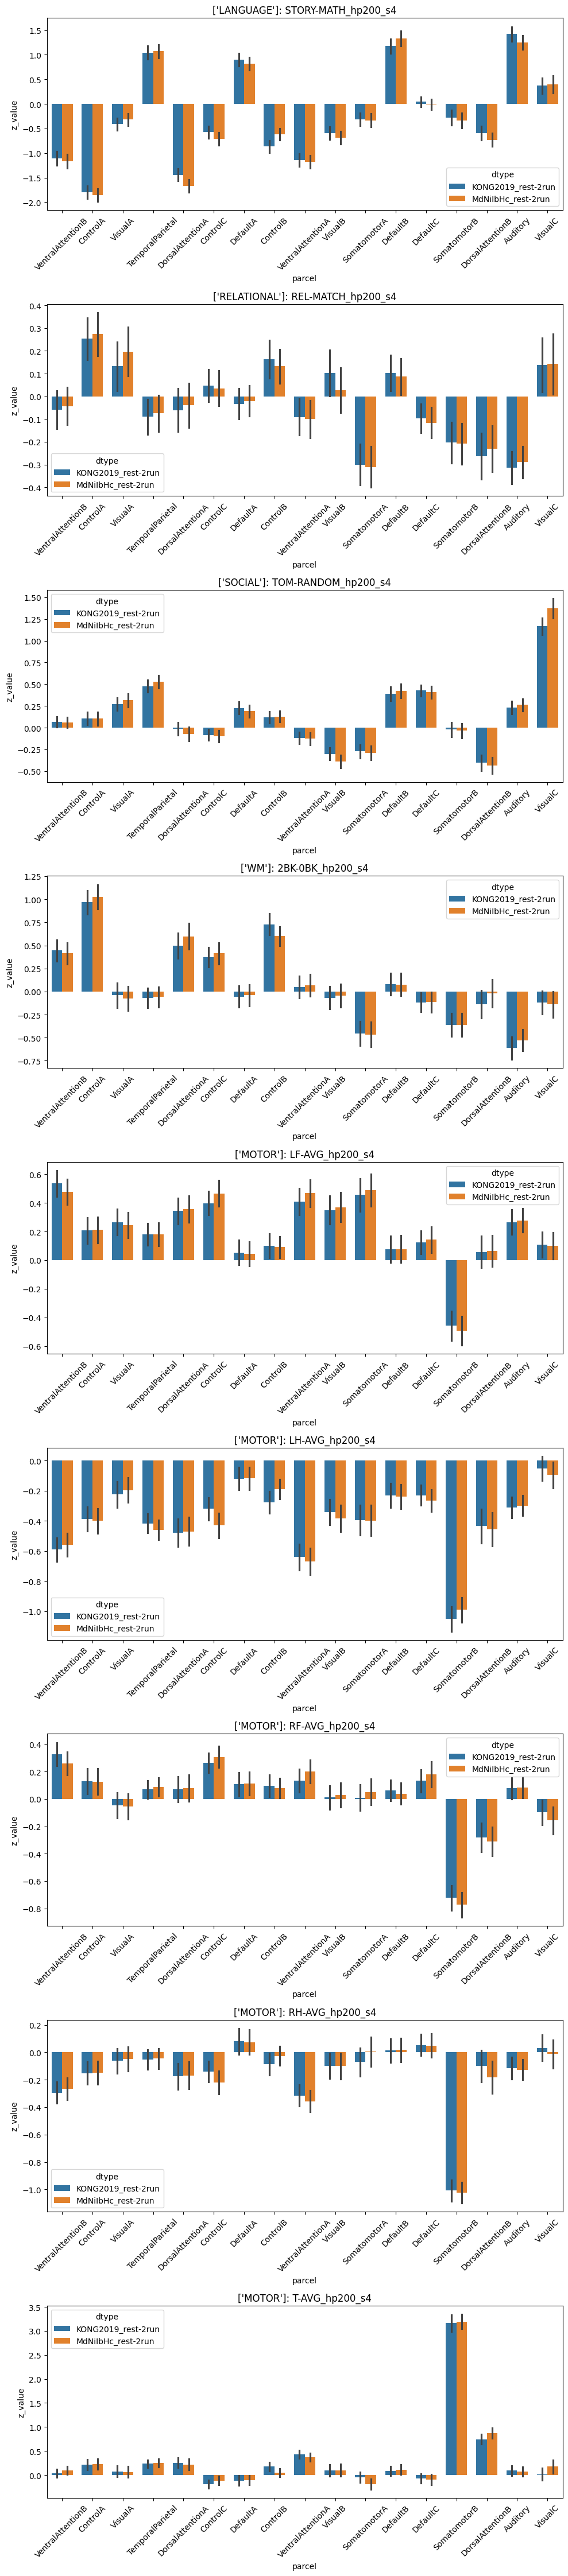

In [17]:
d_type = ['KONG2019_rest-2run', 'MdNiIbHc_rest-2run']
res1 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_KONG2019+HCPrest-2run-indiv_K-17_strengh-10_spatial-5_sm4_1.npy')

res2 = np.load(MODEL_DIR + f'/Models_03/indiv_parcellation/HCP203_test_set/zvalues' +
              '/zvalue_indiv_asym_MdNiIbHc+HCPrest-2run-indiv_K-17_strengh-20_spatial-5_sm4_1.npy')

kong2019, net_name, colors = get_kong2019_17_parcellation()
df_all = pd.DataFrame()
for j, res in enumerate([res1,res2]):
    for i in [9,33,39,42,14,15,16,17,18]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all['contrast_name']=[s.rstrip('_hp200_s2_MSMAll') for s in df_all.contrast_name]

con_nam = df_all['contrast_name'].unique()

plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()

## DCBC/inhomogeneity by task domains

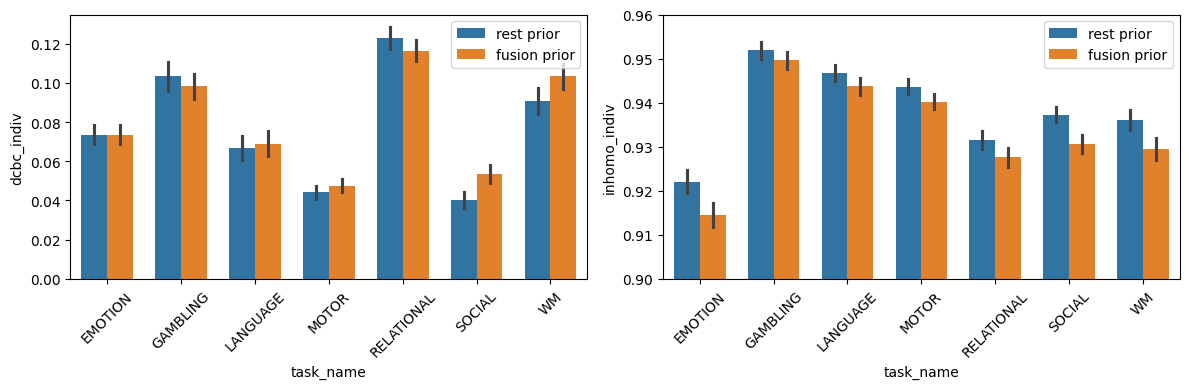

In [16]:
res1 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_MdNiIbHc+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast-split_sm4_group-20_spatial-5_1.tsv', sep='\t')
res2 = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_KONG2019+HCPrest-2run_K-17_indiv-mRBM_test_on_HCPtask-contrast-split_sm4_group-10_spatial-5_1.tsv', sep='\t')
res1['type'] = 'fusion prior'
res2['type'] = 'rest prior'
results = pd.concat([res2, res1], ignore_index=True)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sb.barplot(data=results, x="task_name", y='dcbc_indiv', hue='type', errorbar="se", width=0.7)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="task_name", y='inhomo_indiv', hue='type', errorbar="se", width=0.7)
plt.ylim(0.9, 0.96)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Whether integrating more task datasets yield better group prior map?

### 1. On K=17 tested on HCP dataset

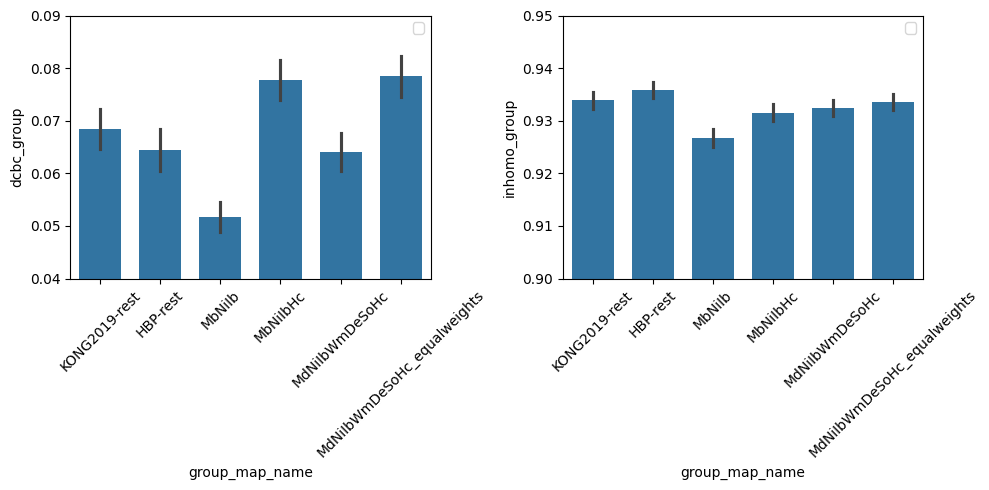

In [15]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group_rest_vs_task_vs_fusion_K-17_on-HCP-contrasts.tsv', sep='\t')
results = results.loc[results.group_map_name != "DU15"]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se", width=0.7)
plt.ylim(0.04, 0.09)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_group', errorbar="se", width=0.7)
plt.ylim(0.9, 0.95)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# from scipy import stats
# a = results.loc[results.group_map_name == 'Fusion(N-feature) DU15init']
# b = results.loc[results.group_map_name == 'HBP15_rest']

# print(stats.ttest_rel(a.dcbc_group, b.dcbc_group))
# print(stats.ttest_rel(a.inhomo_group, b.inhomo_group))

### On K=15 tested on RANDY15 dataset

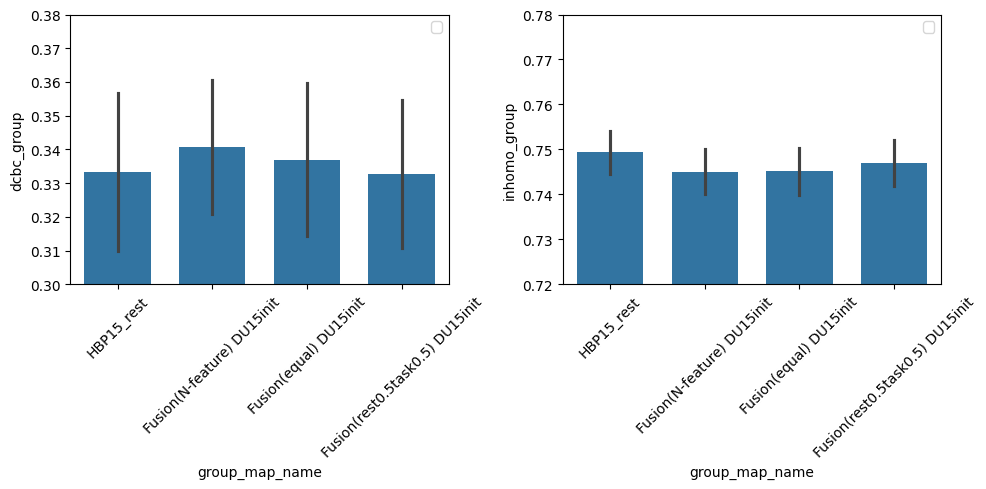

TtestResult(statistic=np.float64(0.6650211295326853), pvalue=np.float64(0.5210781807248944), df=np.int64(10))
TtestResult(statistic=np.float64(-6.2237969857171755), pvalue=np.float64(9.835101765498641e-05), df=np.int64(10))


In [10]:
results = pd.read_csv(f'/data/tge/dzhi/Indiv_par/Evaluations/eval_group_rest_vs_fusion_K-15_on-RANDY-contrasts_sm2_11subjects_new.tsv', sep='\t')
results = results.loc[results.group_map_name != "DU15"]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_group', errorbar="se", width=0.7)
plt.ylim(0.3, 0.38)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_group', errorbar="se", width=0.7)
plt.ylim(0.72, 0.78)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

from scipy import stats
a = results.loc[results.group_map_name == 'Fusion(N-feature) DU15init']
b = results.loc[results.group_map_name == 'HBP15_rest']

print(stats.ttest_rel(a.dcbc_group, b.dcbc_group))
print(stats.ttest_rel(a.inhomo_group, b.inhomo_group))

# (result 4) Replication on RANDY dataset

## Rest-only prior vs. Fusion prior (using all runs resting state data)

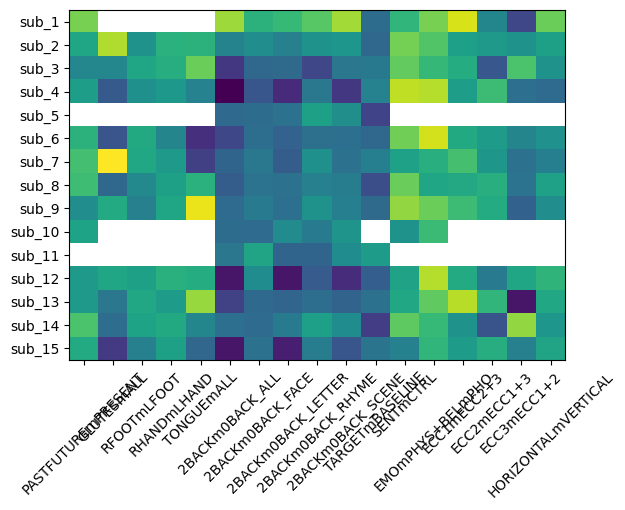

In [24]:
t_data, t_info = ut.load_randy_contrasts(space='fs32k', subj=None, hemis=None, smooth=2)
# randy_con = np.where(np.isnan(t_data[0][:,:,0]), np.nan, 1)


plt.imshow(t_data[0][:,:,0], aspect=0.8)
plt.xticks(ticks=np.arange(17), labels=t_info.contrast_name)
plt.yticks(ticks=np.arange(15), labels=[f'sub_{i}' for i in range(1,16)])

# Optional: rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.show()

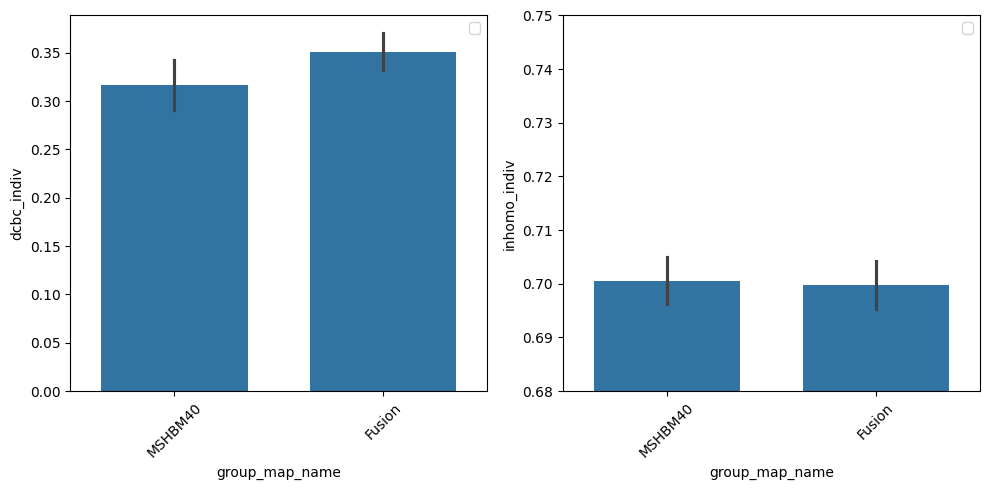

In [37]:
df1 = pd.read_csv('/data/tge/dzhi/Indiv_par/Evaluations/eval_MSHBM40+RANDYrest-allrun_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df2 = pd.read_csv('/data/tge/dzhi/Indiv_par/Evaluations/eval_MdNiIbHc+RANDYrest-allrun_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df1 = df1.loc[(df1.strength==1) & (df1.spatial_w==1)]
df2 = df2.loc[(df2.strength==1) & (df2.spatial_w==1)]
df2.group_map_name = "Fusion"

results = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="group_map_name", y='dcbc_indiv', errorbar="se", width=0.7)
# plt.ylim(0.3, 0.38)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="group_map_name", y='inhomo_indiv', errorbar="se", width=0.7)
plt.ylim(0.68, 0.75)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### This is because the group prior is less important when there are more individual data (runs), in other words: The fusion group prior improves individual parcellation is conditional and more pronunced on limited data

TtestResult(statistic=np.float64(0.3693051468107902), pvalue=np.float64(0.7196001554945264), df=np.int64(10))
TtestResult(statistic=np.float64(-2.4546636166724953), pvalue=np.float64(0.03398545698259374), df=np.int64(10))


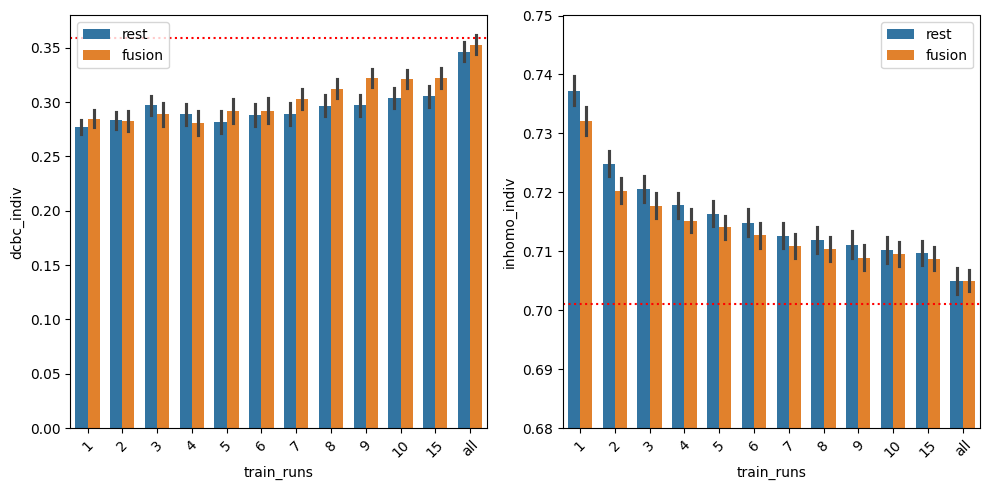

In [48]:
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
du15 = pd.read_csv(RES_DIR + '/eval_DU15_indiv_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df_rest = pd.read_csv(RES_DIR + '/eval_HBPHc+RANDYrest-1to15run_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df_fusion = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYrest-1to15run_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv',sep='\t')
df_rest_all = pd.read_csv(RES_DIR + '/eval_HBPHc+RANDYrest-allrun_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df_fusion_all = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYrest-allrun_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')
df_rest = pd.concat([df_rest, df_rest_all], ignore_index=True)
df_fusion = pd.concat([df_fusion, df_fusion_all], ignore_index=True)

df_rest = df_rest.loc[(df_rest["spatial_w"] == 0)]
df_fusion = df_fusion.loc[(df_fusion["spatial_w"] == 0)]
df_rest['group_map_name'] = 'rest'
df_fusion['group_map_name'] = 'fusion'
results = pd.concat([df_rest, df_fusion], ignore_index=False)

from scipy import stats
a = df_rest.groupby(['subj_num', 'train_runs']).mean(numeric_only=True).reset_index()
b = df_fusion.groupby(['subj_num', 'train_runs']).mean(numeric_only=True).reset_index()

print(stats.ttest_rel(du15.dcbc_indiv, b.loc[b["train_runs"]=='all'].dcbc_indiv))
print(stats.ttest_rel(du15.inhomo_indiv, b.loc[b["train_runs"]=='all'].inhomo_indiv))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="train_runs", y='dcbc_indiv', hue='group_map_name', errorbar="se", width=0.7)
plt.axhline(y=du15.dcbc_indiv.mean(), color='r', linestyle=':')
# plt.ylim(0.3, 0.38)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="train_runs", y='inhomo_indiv', hue='group_map_name', errorbar="se", width=0.7)
 
plt.ylim(0.68, 0.75)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

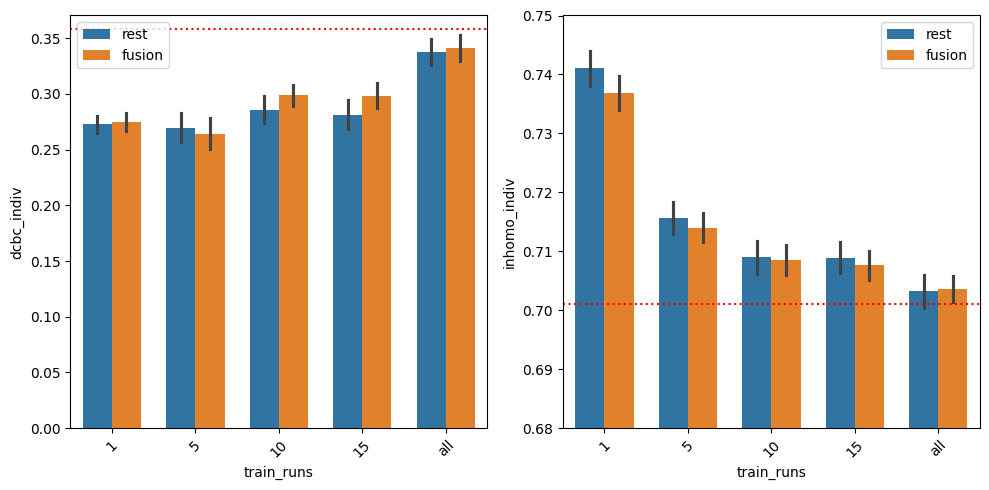

TtestResult(statistic=np.float64(5.734550328208164), pvalue=np.float64(0.00018912510915388258), df=np.int64(10))
TtestResult(statistic=np.float64(3.1307091236367404), pvalue=np.float64(0.010677602034488079), df=np.int64(10))
TtestResult(statistic=np.float64(0.5137125394398224), pvalue=np.float64(0.6186119259437146), df=np.int64(10))
TtestResult(statistic=np.float64(2.1531470077039985), pvalue=np.float64(0.05676228135420219), df=np.int64(10))


In [27]:
results = results.loc[(results["train_runs"] == 1) | (results["train_runs"] == 5) | (results["train_runs"] == 10) |
                           (results["train_runs"] == 15) |  (results["train_runs"] == 'all')]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sb.barplot(data=results, x="train_runs", y='dcbc_indiv', hue='group_map_name', errorbar="se", width=0.7)
plt.axhline(y=du15.dcbc_indiv.mean(), color='r', linestyle=':')
# plt.ylim(0.3, 0.38)
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1,2,2)
sb.barplot(data=results, x="train_runs", y='inhomo_indiv', hue='group_map_name', errorbar="se", width=0.7)
plt.axhline(y=du15.inhomo_indiv.mean(), color='r', linestyle=':')
plt.ylim(0.68, 0.75)
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

print(stats.ttest_rel(a.loc[a["train_runs"]==1].inhomo_indiv, b.loc[b["train_runs"]==1].inhomo_indiv))
print(stats.ttest_rel(a.loc[a["train_runs"]==5].inhomo_indiv, b.loc[b["train_runs"]==5].inhomo_indiv))
print(stats.ttest_rel(a.loc[a["train_runs"]==10].inhomo_indiv, b.loc[b["train_runs"]==10].inhomo_indiv))
print(stats.ttest_rel(a.loc[a["train_runs"]==15].inhomo_indiv, b.loc[b["train_runs"]==15].inhomo_indiv))

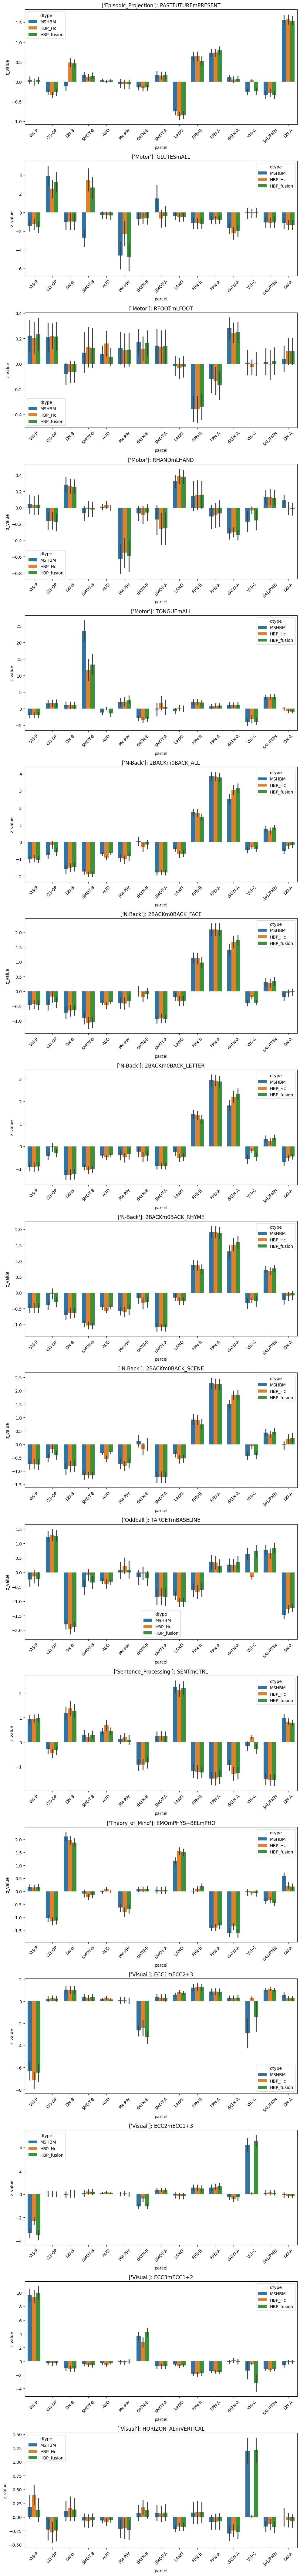

In [46]:
d_type = ['MSHBM', 'HBP_Hc', 'HBP_fusion']
color_list = [tuple(color) for color in colors[1:,:]]

res1 = np.load(f'/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MSHBM40+RANDYrest-1run-indiv_K-15_strengh-1_spatial-1_sm2.npy')

res2 = np.load('/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_HBPHc+RANDYrest-1run-indiv_K-15_strengh-2_spatial-1_sm2.npy')

res3 = np.load('/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              '/zvalue_indiv_asym_MdNiIbHc+RANDYrest-1run-indiv_K-15_strengh-2_spatial-5_sm2.npy')

df_all = pd.DataFrame()
for j, res in enumerate([res1,res2,res3]):
    for i in range(17):
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

con_nam = df_all['contrast_name'].unique()
plt.figure(figsize=(10, 5 * len(con_nam)))

for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
plt.show()